In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import lightgbm as lgb

In [3]:
import sys
sys.path.append("../..")

from regression import simple_regression, cross_gen, interaction_regression, huber_regression, decision_tree, random_forest, extra_trees, xgboost_model, lightgbm_model, gpr_matern, gpr_rational_quadratic, ann, predict_gpr_in_batches

In [4]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/5sec_50%overlap/data"

train_path = os.path.join(DATA_DIR, "SBP_RELIEFF_train.csv")
val_path   = os.path.join(DATA_DIR, "SBP_RELIEFF_val.csv")
test_path  = os.path.join(DATA_DIR, "SBP_RELIEFF_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (829483, 16)
Val:   (104736, 16)
Test:  (105176, 16)


In [5]:
TARGET = "SBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (829483, 15)
y_train: (829483,)
X_val:   (104736, 15)
y_val:   (104736,)
X_test:  (105176, 15)
y_test:  (105176,)


In [6]:
VITAL_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/5sec_50%overlap/data/SBP_RELIEFF_vitaldb.csv"
vital_test = pd.read_csv(VITAL_PATH)
print(vital_test.shape)
print(df_train.head())

(9271840, 17)
   vpg_mean  apg_mean  apg_zero_crossing_rate  apg_median  vpg_median  \
0 -0.426272 -1.394359               -0.931305   -1.594106   -2.836776   
1 -1.517758 -0.163156                0.472676   -1.409760   -3.109268   
2 -0.861609  0.600172                0.940669   -1.349989   -3.246622   
3  1.064260  1.400409                0.472676   -1.210387   -3.144472   
4  1.924317 -0.373121               -0.580310   -1.434122   -2.776534   

   apg_skewness  ppg_energy_variance  vpg_skewness  vpg_shannon_entropy  \
0      2.778702             0.555625     -0.521950             0.111919   
1      2.593202             0.901286     -0.303971            -0.027732   
2      2.506303             1.473660     -0.268875             0.010860   
3      2.393785             1.188938     -0.565650             0.326498   
4      2.502233             1.147315     -0.802773             0.735309   

   vpg_zero_crossing_rate  ppg_variance   ppg_std  ppg_shannon_entropy  \
0               -0.734

In [7]:
X_test_vital = vital_test.drop(columns=[TARGET, "case_id"])
y_test_vital = vital_test[TARGET]

In [8]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [9]:
print("SBP min:", y_train.min())
print("SBP max:", y_train.max())
print("SBP mean:", y_train.mean())
print("SBP std:", y_train.std())

print("SBP > 80:", np.sum(y_train > 80))
print("SBP > 90:", np.sum(y_train > 90))
print("SBP > 100:", np.sum(y_train > 100))

SBP min: 72.48465074023241
SBP max: 199.3622907516529
SBP mean: 129.94175380628658
SBP std: 22.028076535061036
SBP > 80: 828714
SBP > 90: 816812
SBP > 100: 768831


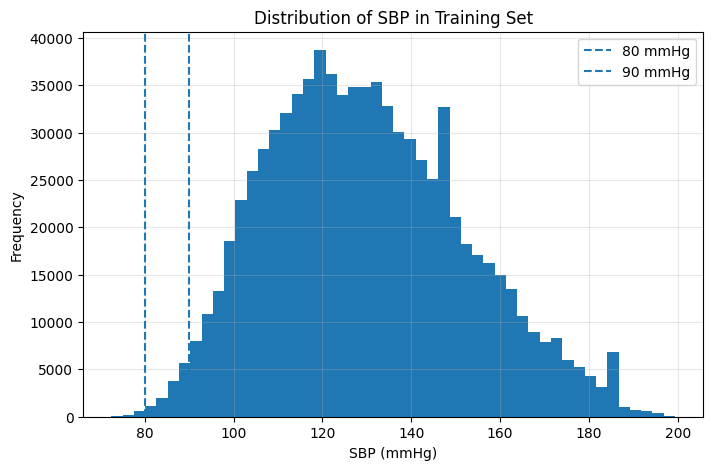

In [10]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=50)

plt.axvline(80, linestyle="--", label="80 mmHg")
plt.axvline(90, linestyle="--", label="90 mmHg")

plt.xlabel("SBP (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of SBP in Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SIMPLE LINEAR REGRESSION ##

Simple Linear Regression
------------------------
Target: SBP
RMSE: 21.8545
MSE : 477.6187
R²  : 0.0952
MAE : 17.5710


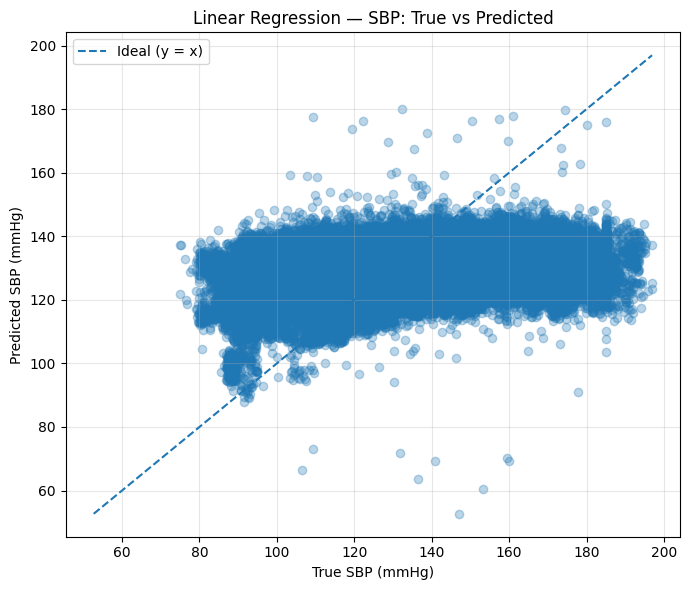

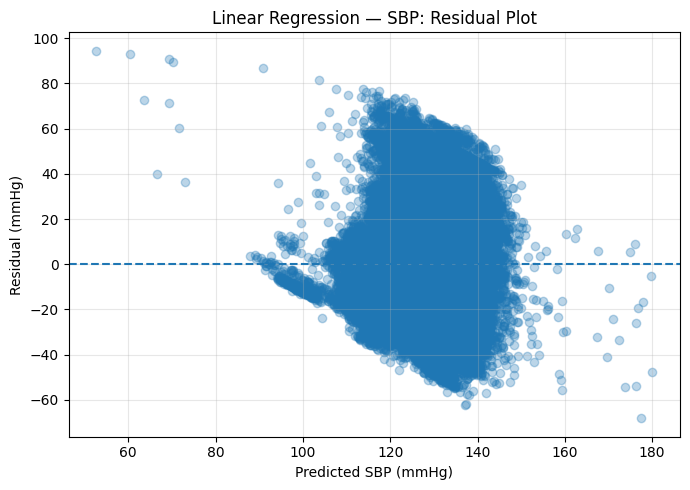

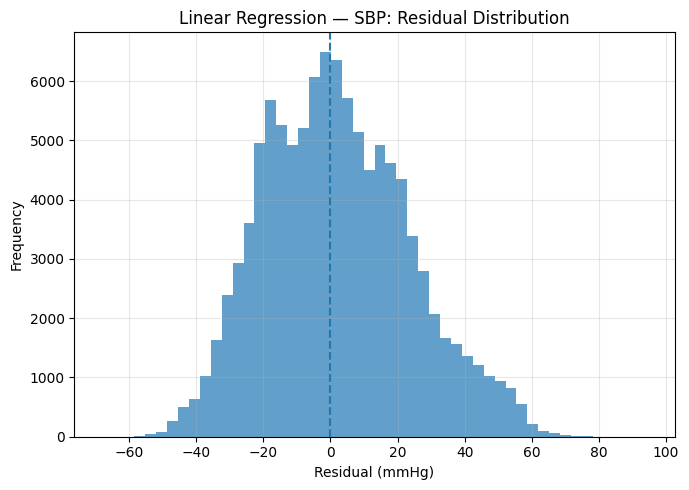

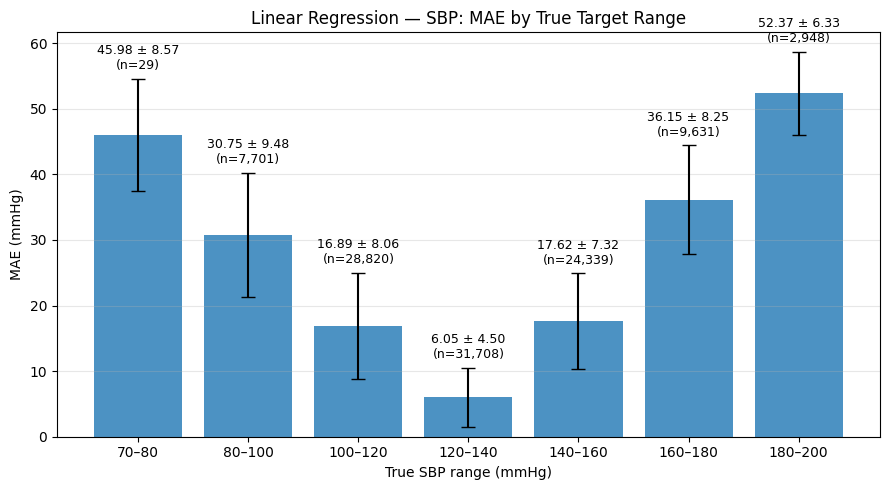

In [11]:
linear_model, y_test_pred = simple_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 58.4908
MSE : 3421.1681
R²  : -7.0046
MAE : 30.4132


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


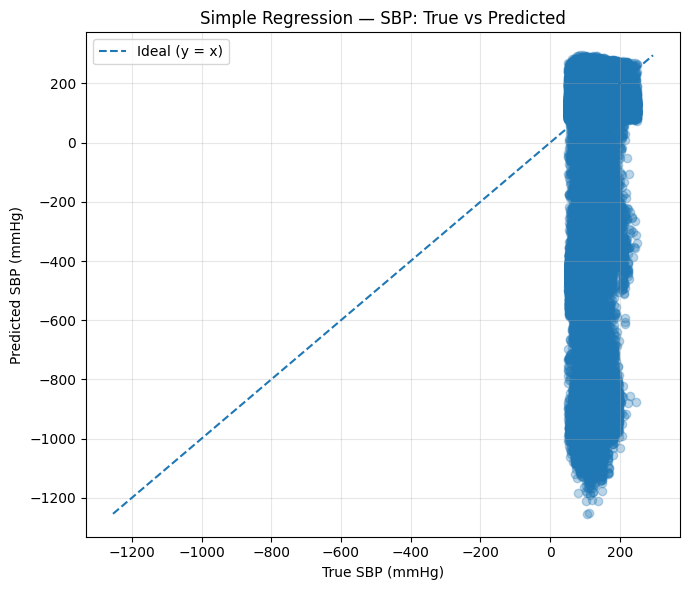

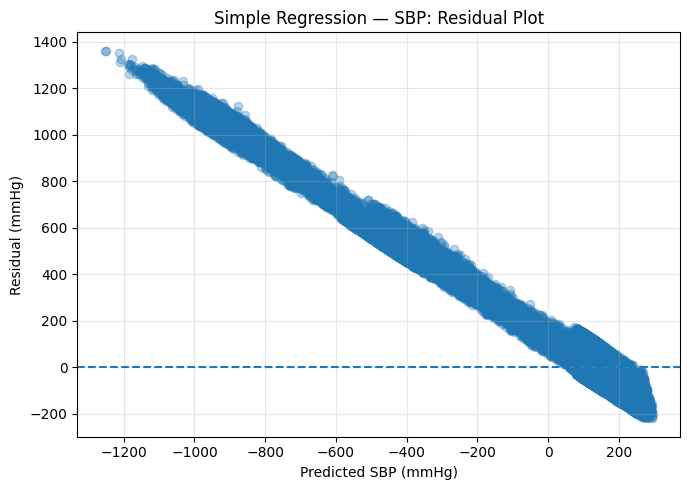

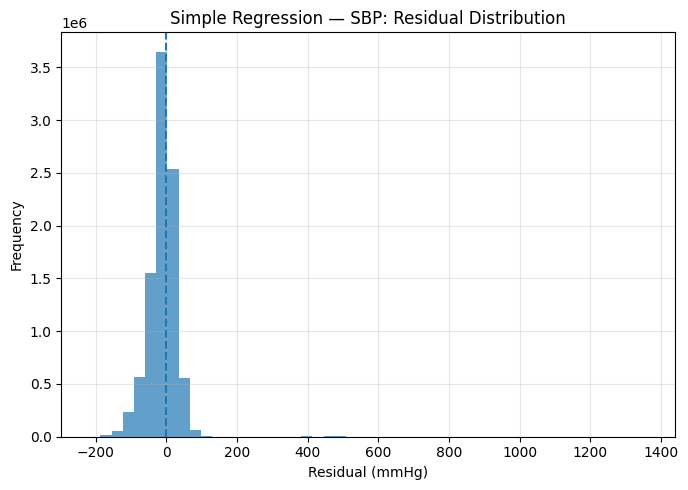

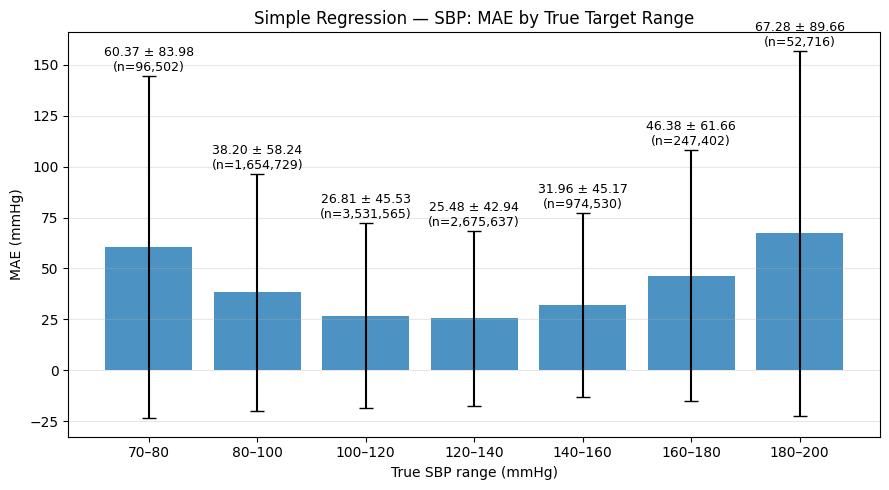

In [12]:
cross_gen(
    X_test_vital,
    y_test_vital,
    linear_model,
    "Simple Regression",
    TARGET
)

## INTERACTION LINEAR REGRESSION ##

Best parameters:
{'linear__fit_intercept': True}

Interaction Linear Regression — SBP
---------------------------------------------
RMSE: 21.1906
MSE : 449.0414
R²  : 0.1493
MAE : 17.0488


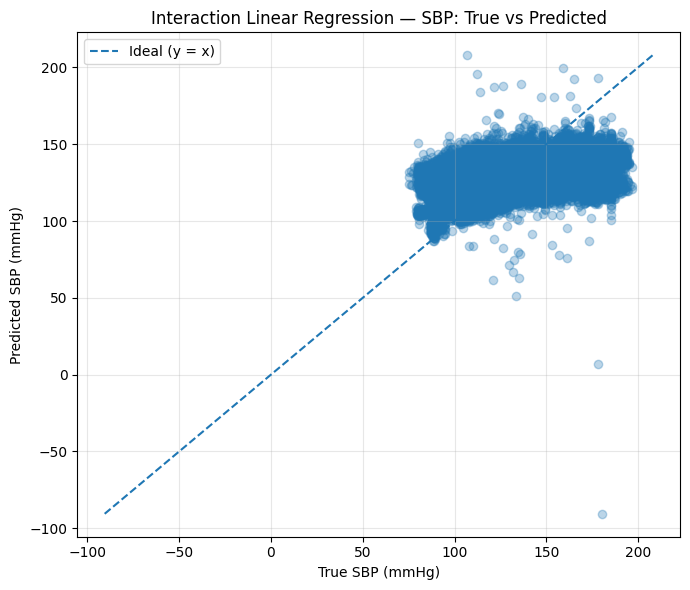

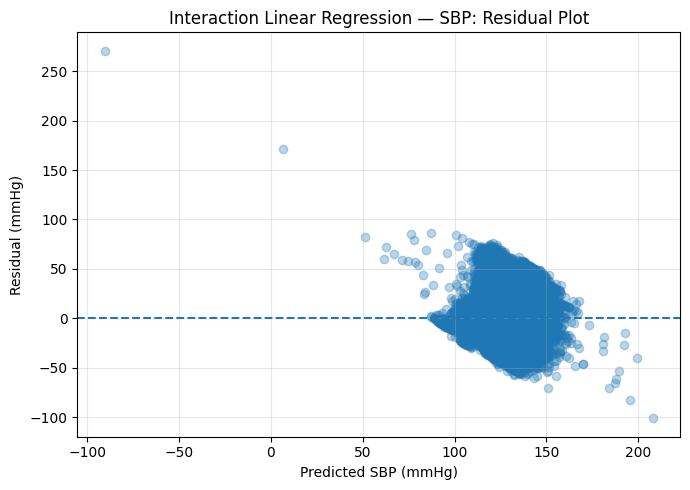

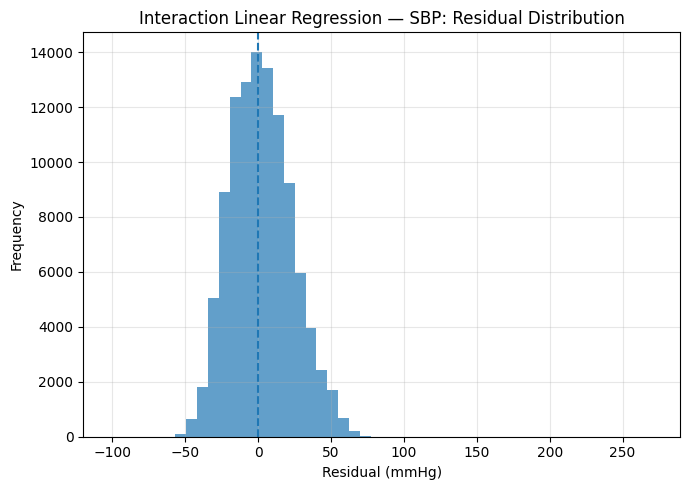

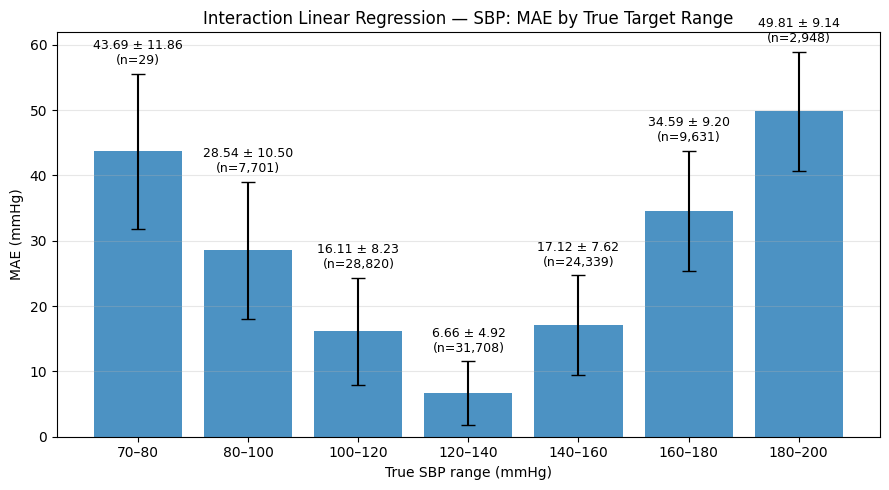

In [13]:
grid_interaction, y_test_pred = interaction_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 2847.1875
MSE : 8106476.9351
R²  : -18965.8559
MAE : 245.5910


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


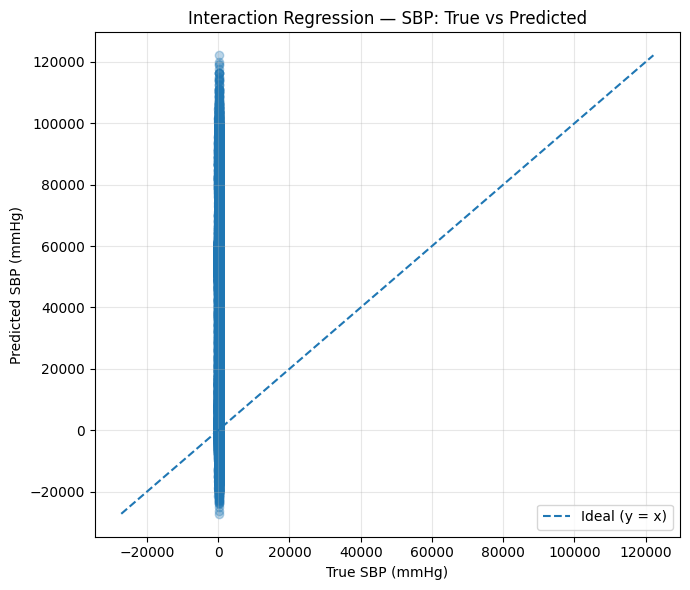

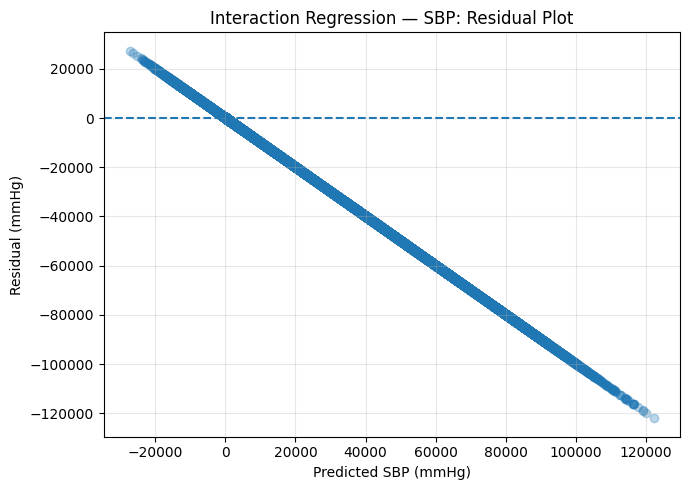

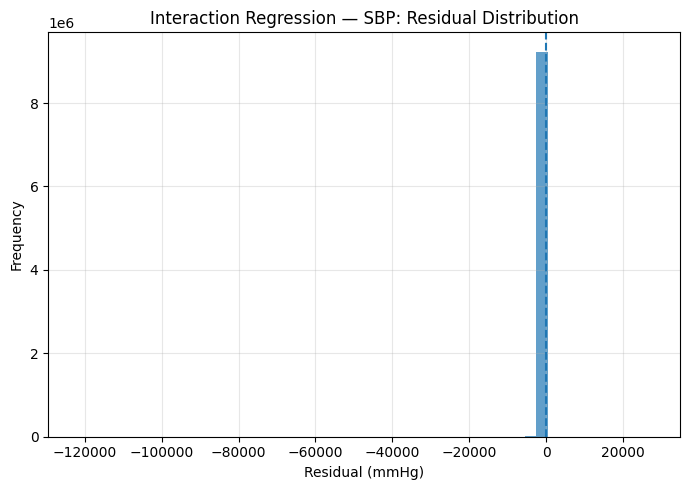

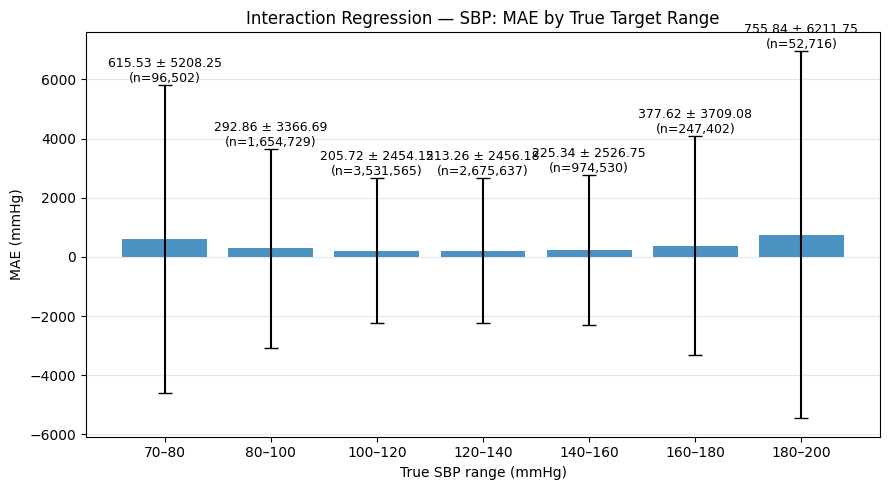

In [14]:
cross_gen(
    X_test_vital,
    y_test_vital,
    grid_interaction,
    "Interaction Regression",
    TARGET
)

## Robust Linear Regression ##

Best parameters:
{'alpha': 1.0, 'epsilon': 2.0}

Robust Linear Regression — SBP
----------------------------------------
RMSE: 21.8784
MSE : 478.6636
R²  : 0.0932
MAE : 17.5649


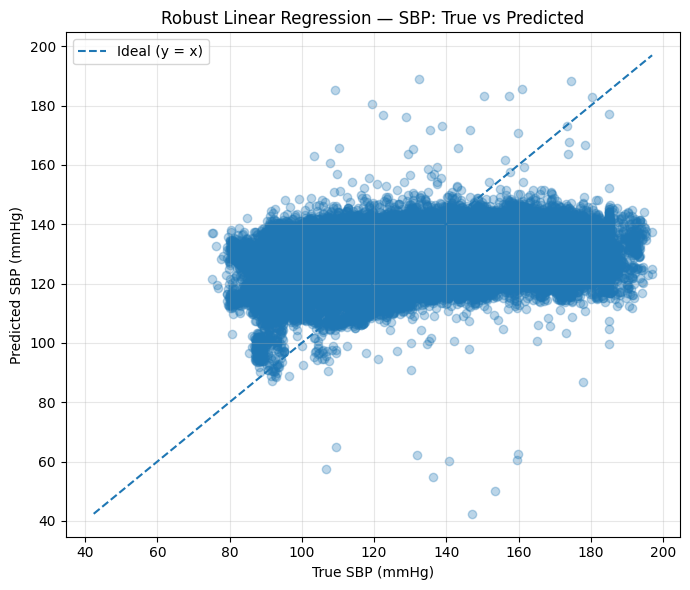

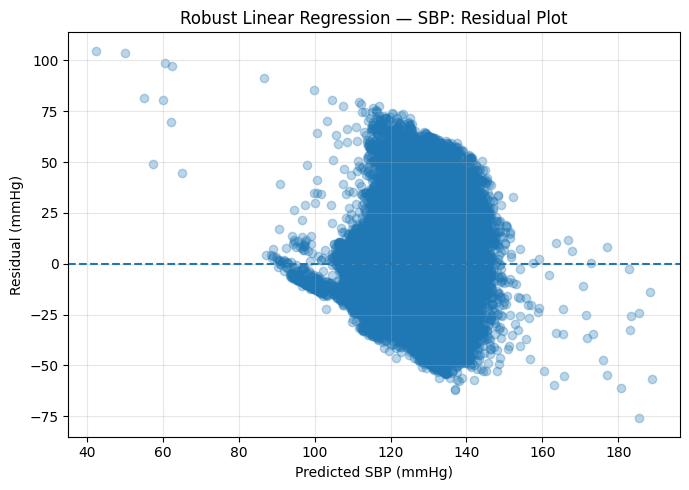

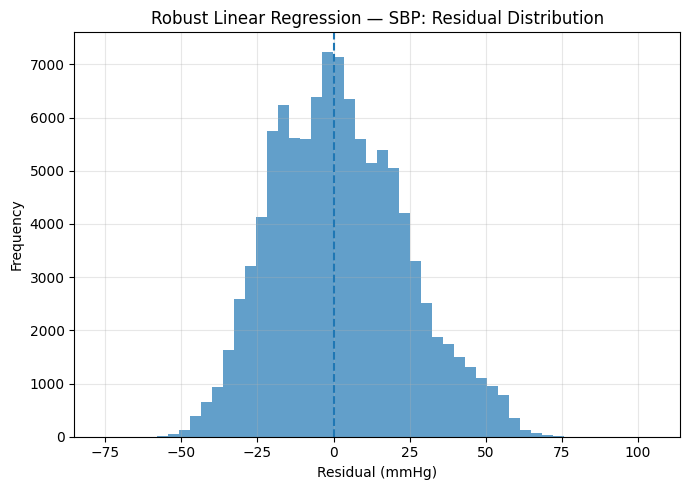

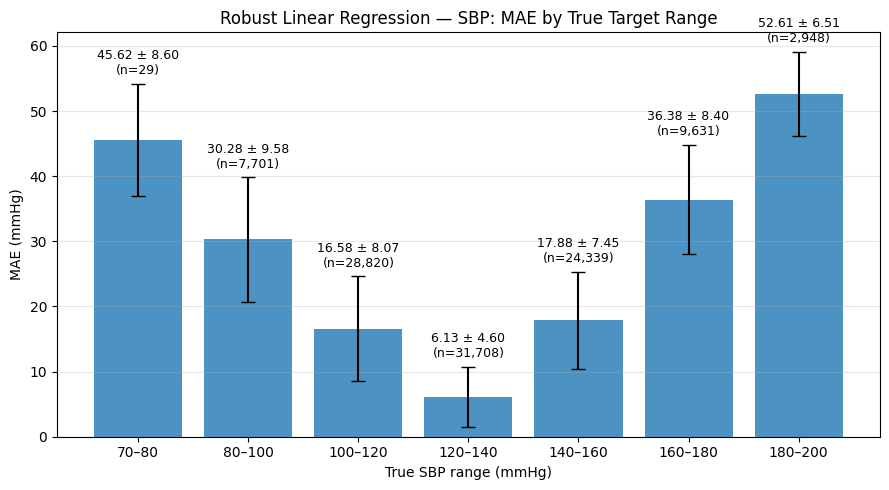

In [15]:
huber_model, y_test_pred = huber_regression(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 58.2224
MSE : 3389.8505
R²  : -6.9313
MAE : 31.1401


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


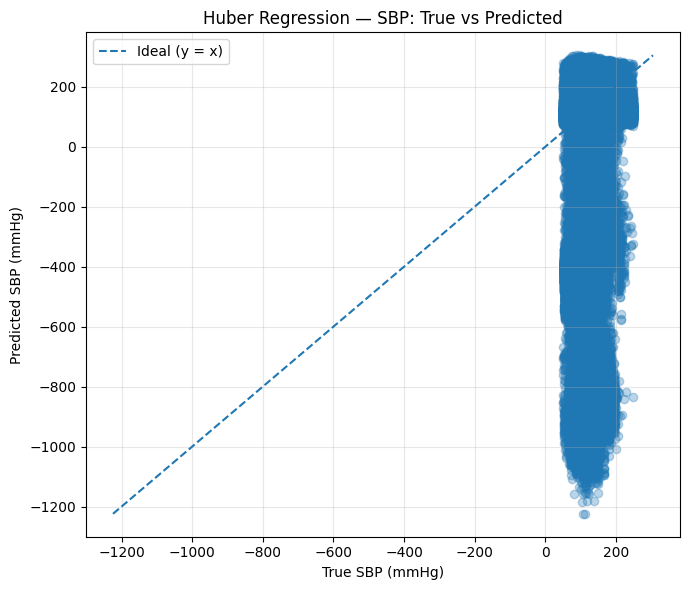

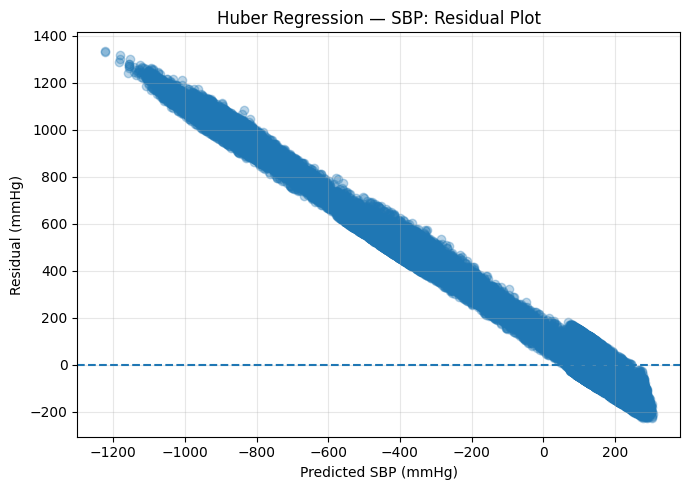

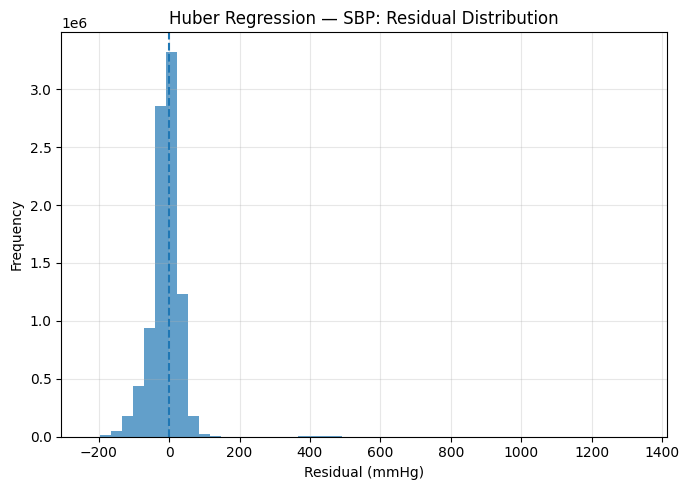

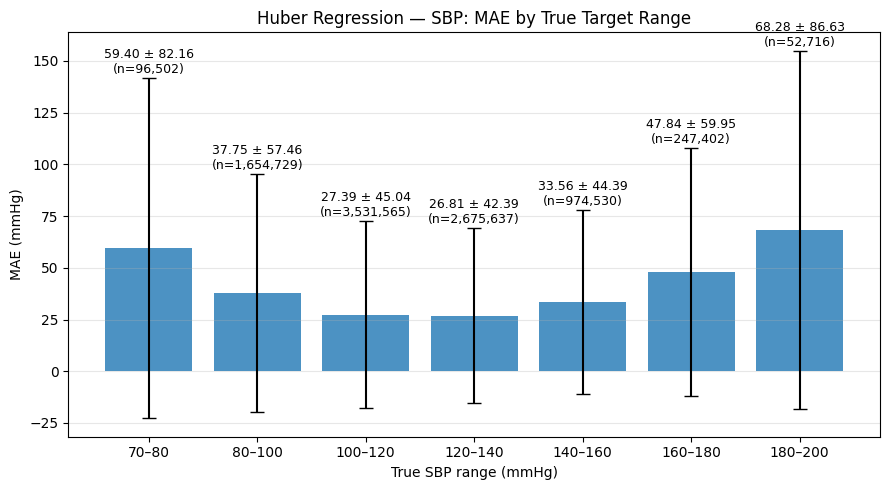

In [16]:
cross_gen(
    X_test_vital,
    y_test_vital,
    huber_model,
    "Huber Regression",
    TARGET
)

## Fine Decision Tree ##

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Fine Decision Tree — SBP
--------------------------------
RMSE: 20.5570
MSE : 422.5896
R²  : 0.1994
MAE : 16.0985


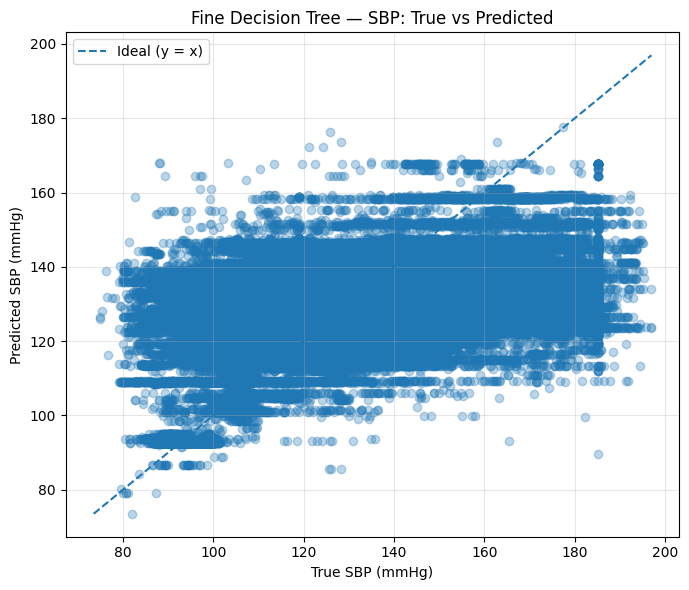

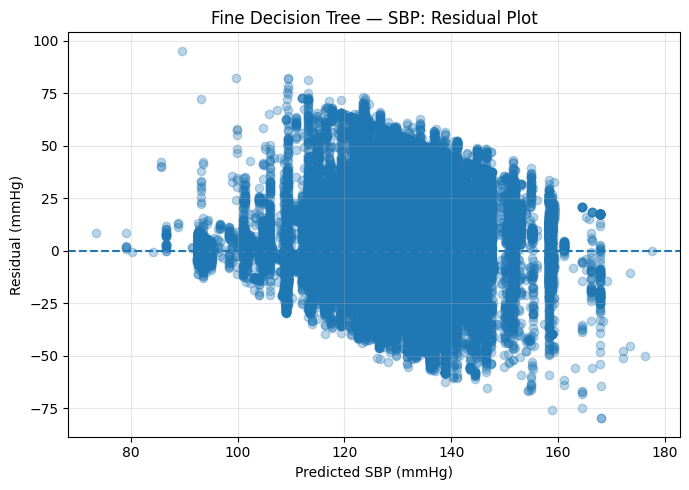

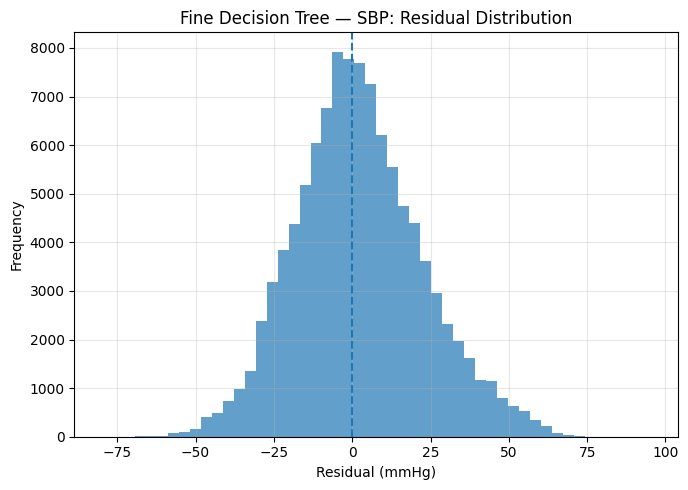

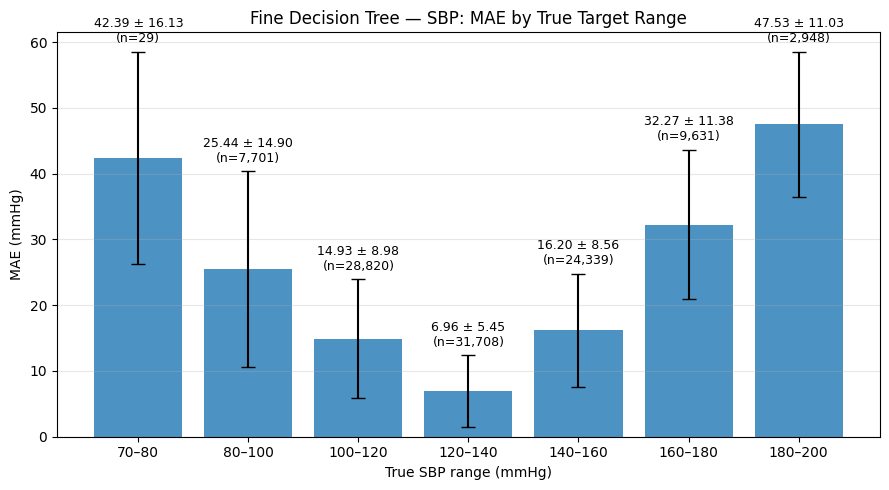

In [17]:
tree_model, y_test_pred = decision_tree(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)


RMSE: 31.4751
MSE : 990.6795
R²  : -1.3179
MAE : 26.0928


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


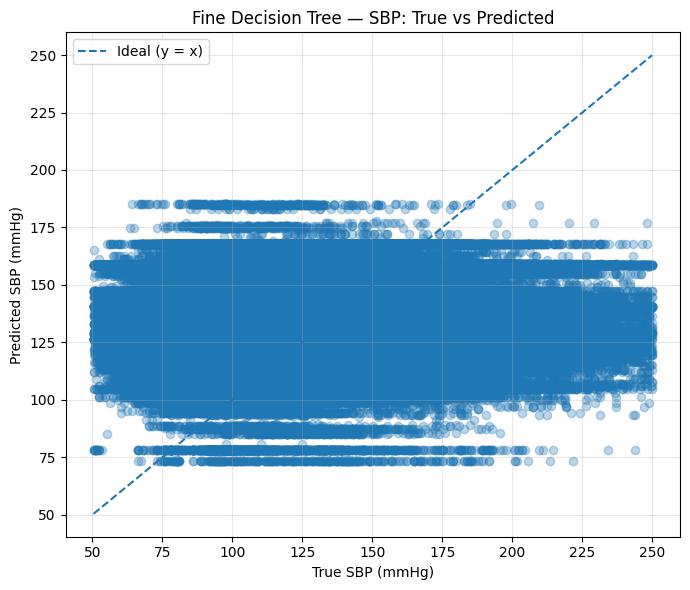

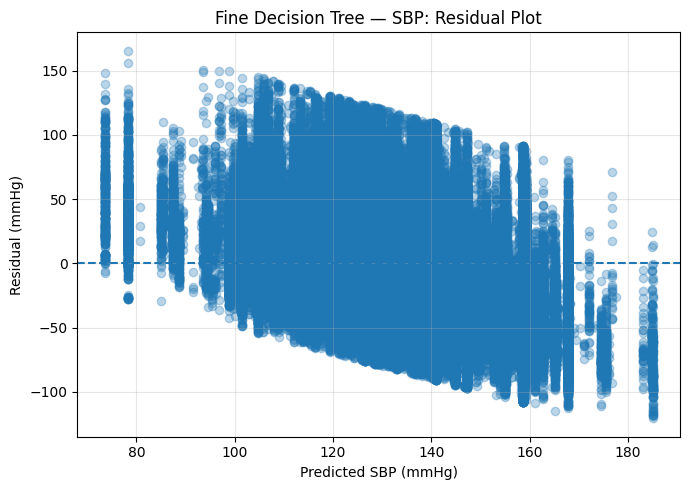

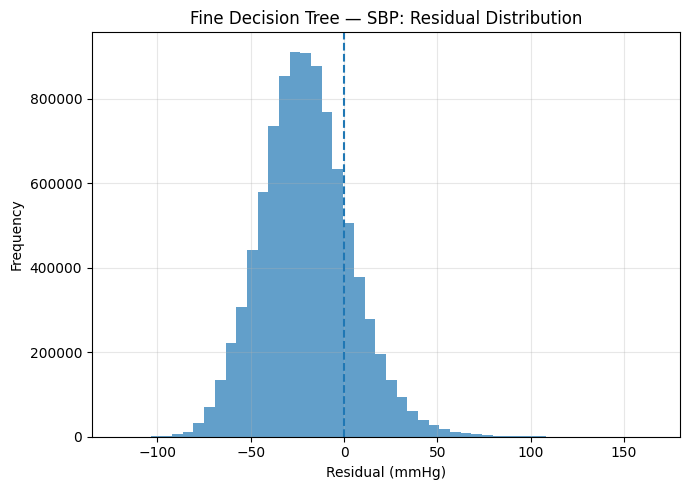

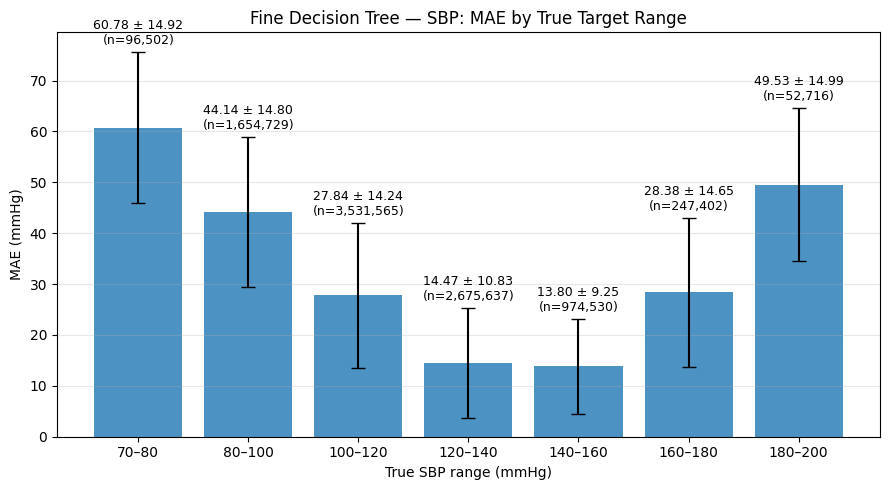

In [18]:
cross_gen(
    X_test_vital,
    y_test_vital,
    tree_model,
    "Fine Decision Tree",
    TARGET
)

## Random Forest ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest — SBP
----------------------------
RMSE: 18.2680
MSE : 333.7197
R²  : 0.3678
MAE : 13.7712


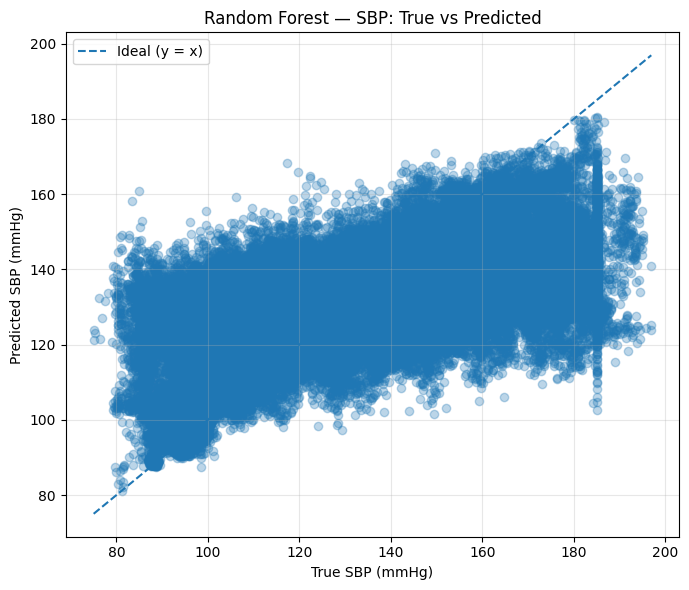

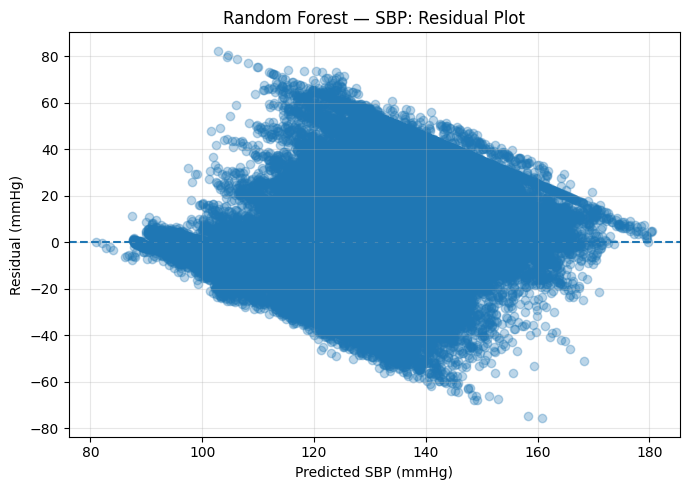

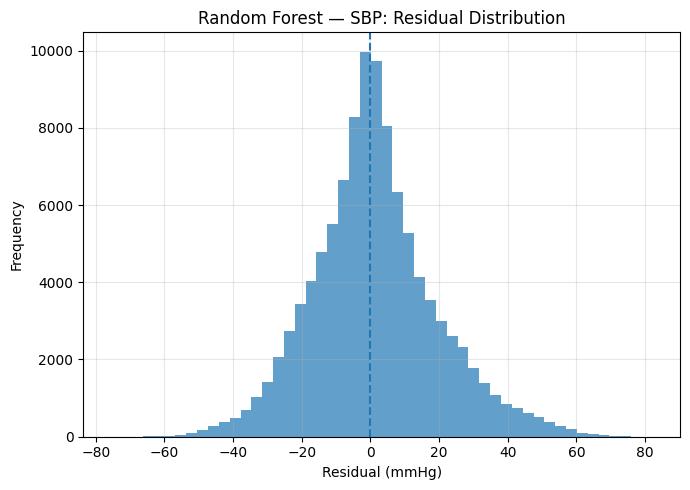

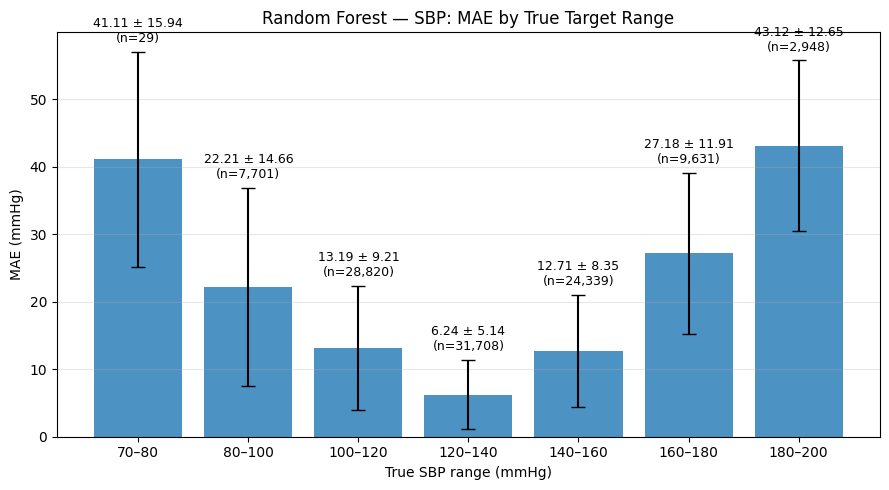

In [19]:
rf_model, y_test_pred = random_forest(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 25.8615
MSE : 668.8152
R²  : -0.5648
MAE : 21.4407


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


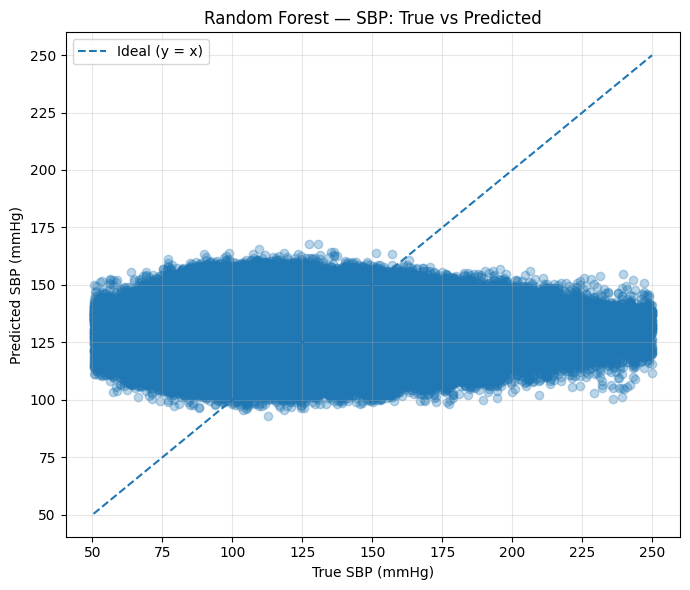

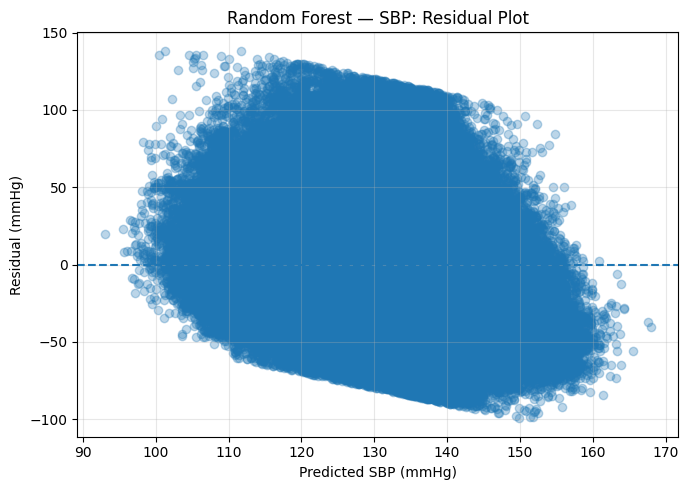

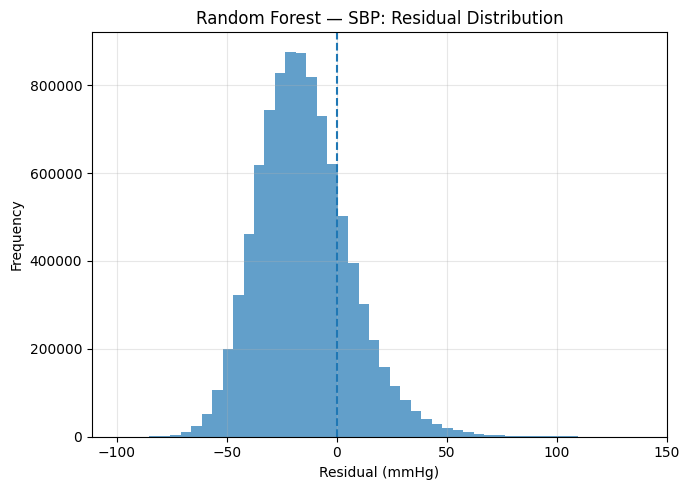

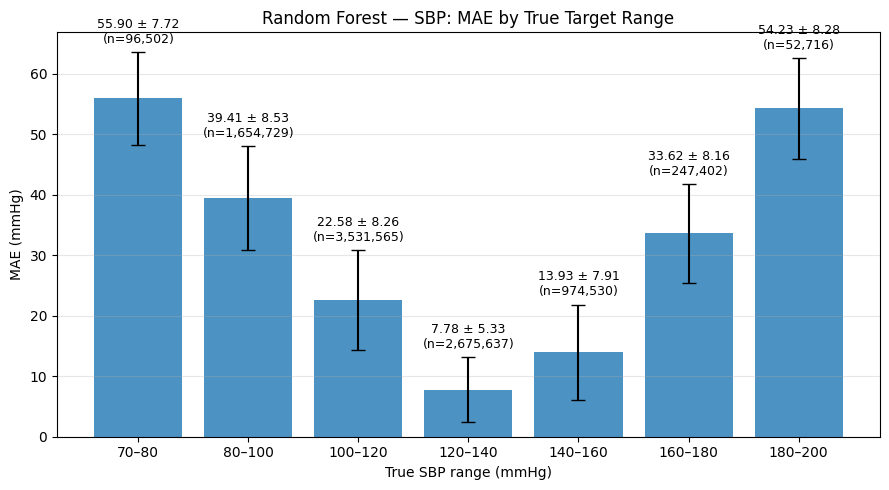

In [20]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rf_model,
    "Random Forest",
    TARGET
)

## Extra TREES ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Extra Trees Regressor — SBP
--------------------------------------
RMSE: 18.1087
MSE : 327.9242
R²  : 0.3788
MAE : 13.4937


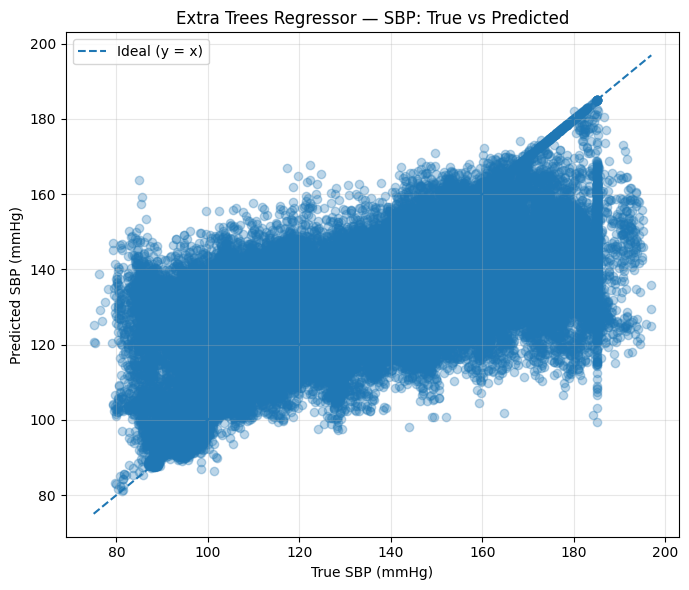

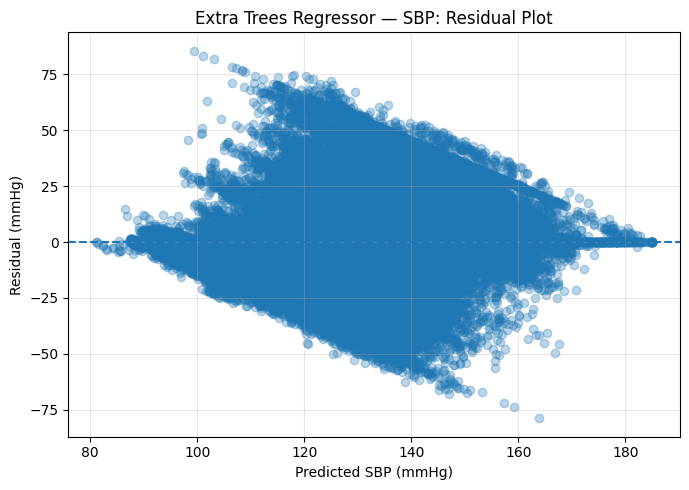

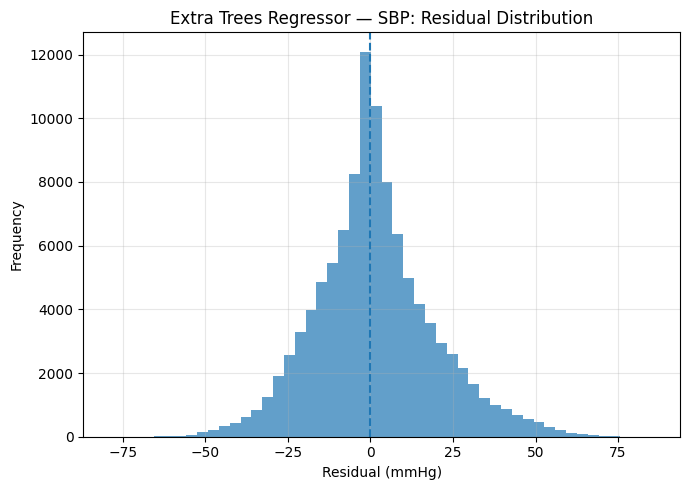

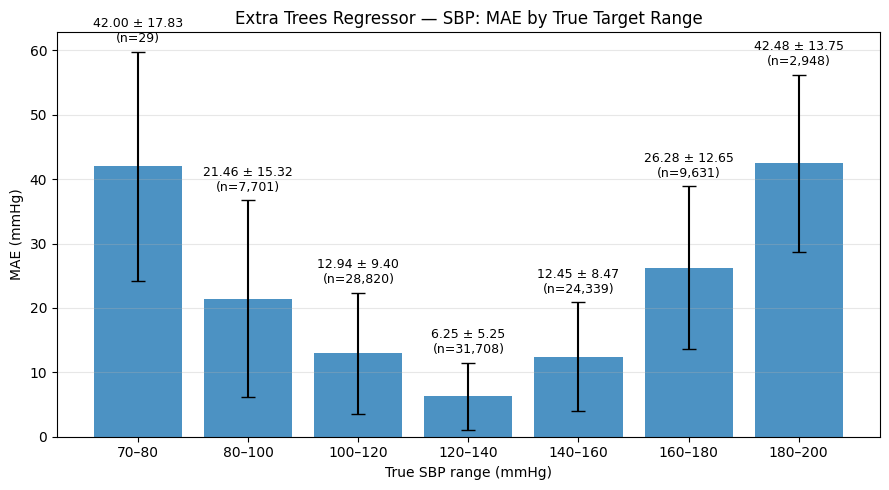

In [21]:
extra_trees_model, y_test_pred = extra_trees(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 26.3537
MSE : 694.5199
R²  : -0.6250
MAE : 21.9287


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


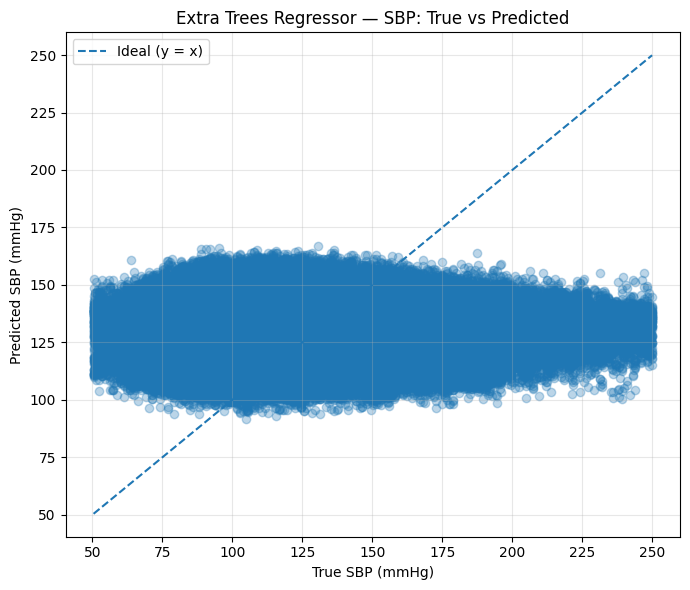

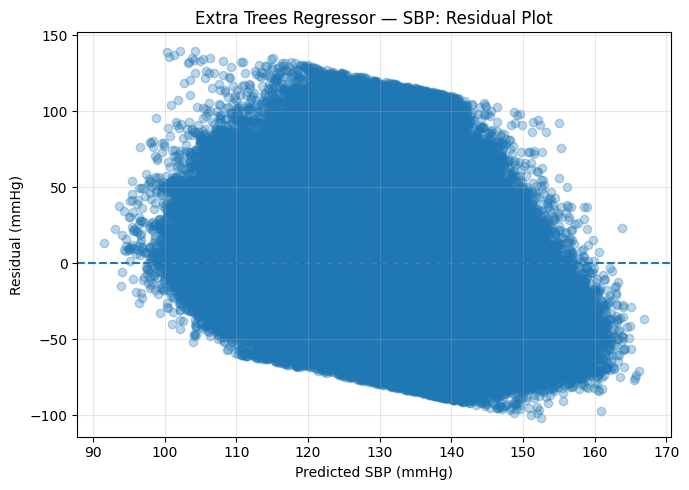

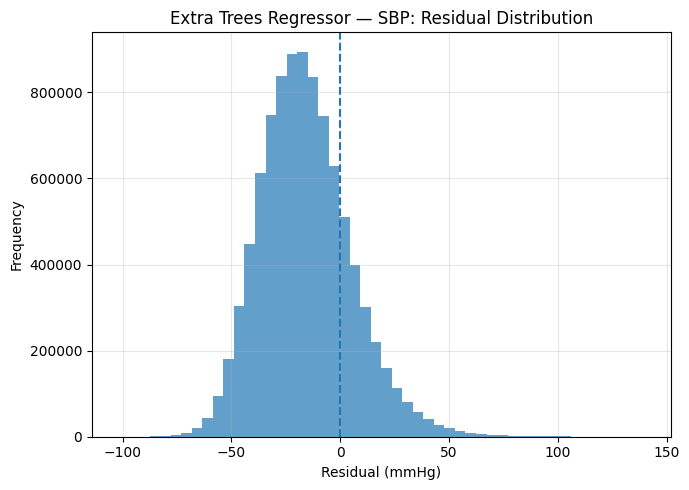

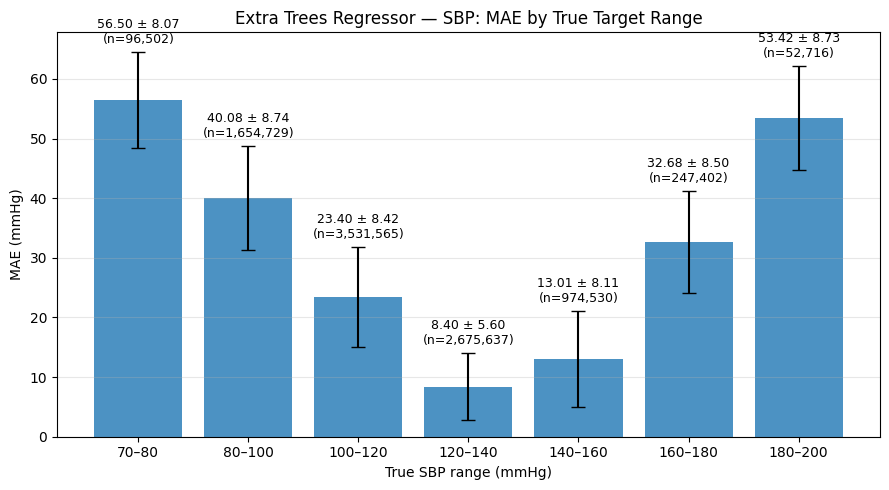

In [22]:
cross_gen(
    X_test_vital,
    y_test_vital,
    extra_trees_model,
    "Extra Trees Regressor",
    TARGET
)

## XGBOOST ##

Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

XGBoost — SBP
---------------------
RMSE: 19.4117
MSE : 376.8148
R²  : 0.2862
MAE : 15.1384


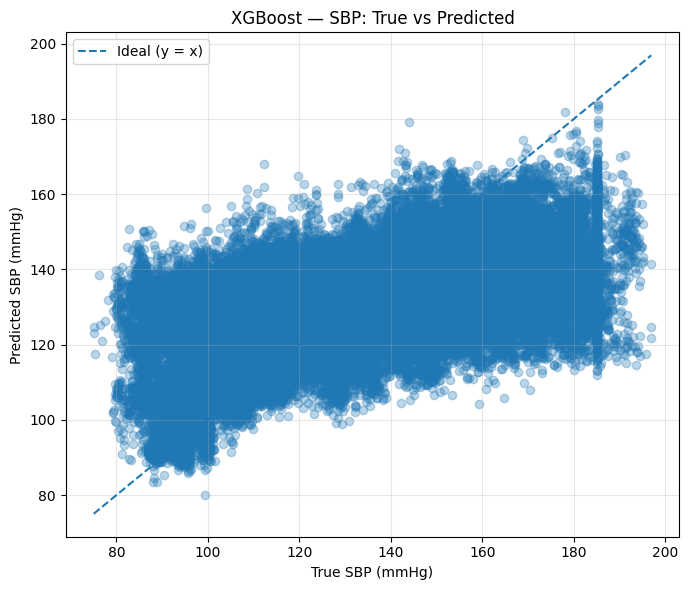

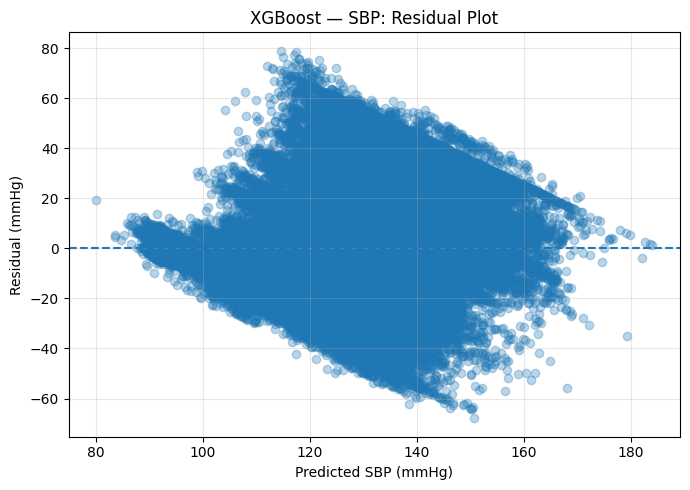

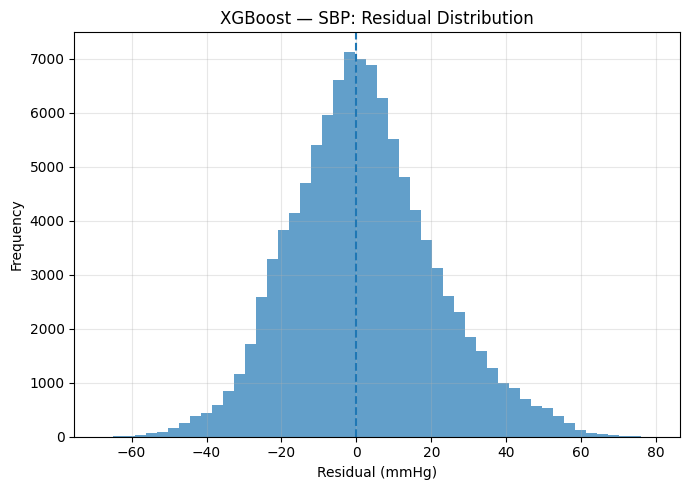

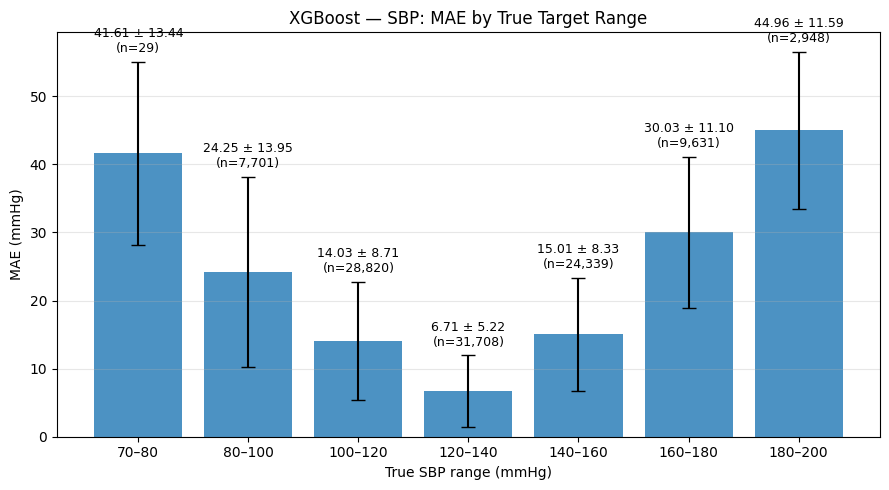

In [23]:
xgbmodel, y_test_pred = xgboost_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 35.3486
MSE : 1249.5220
R²  : -1.9235
MAE : 29.4460


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


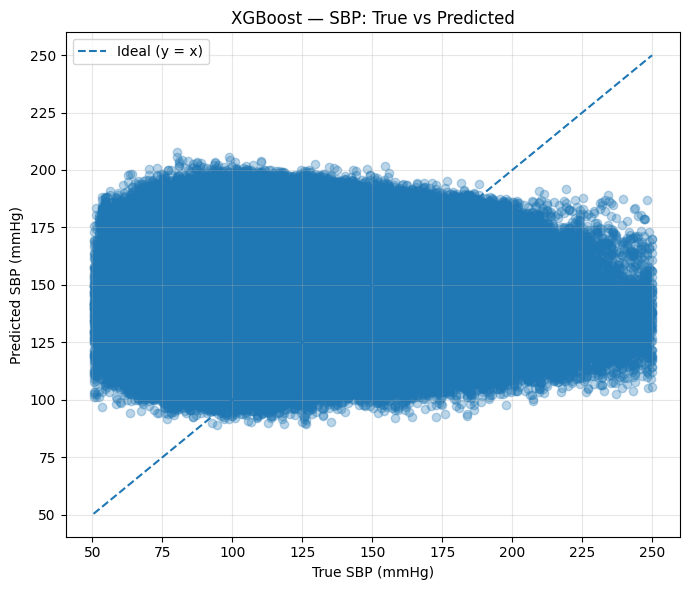

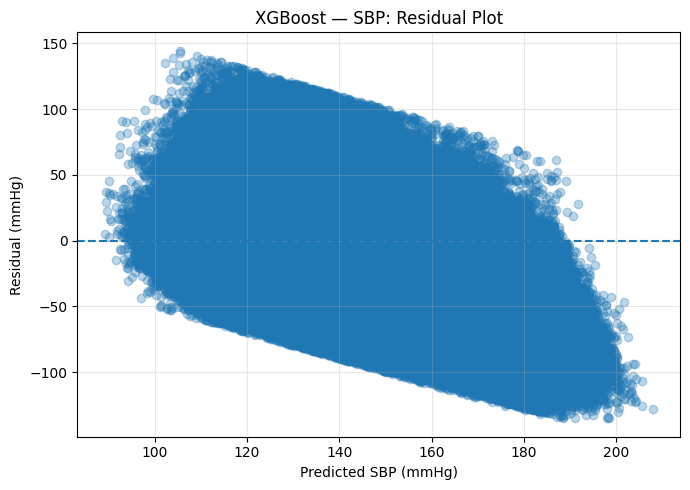

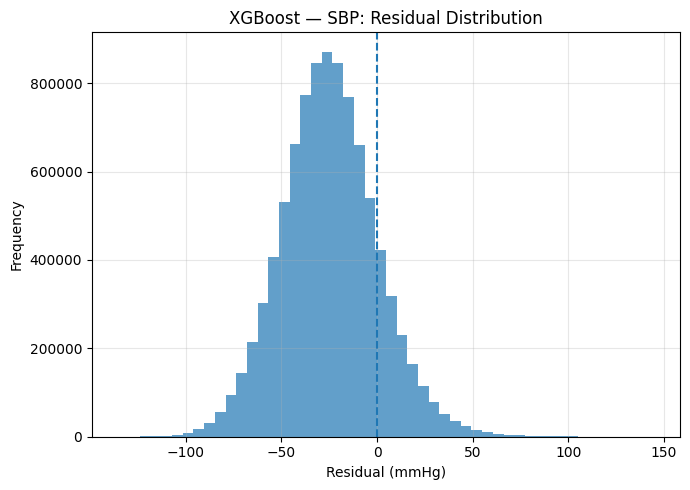

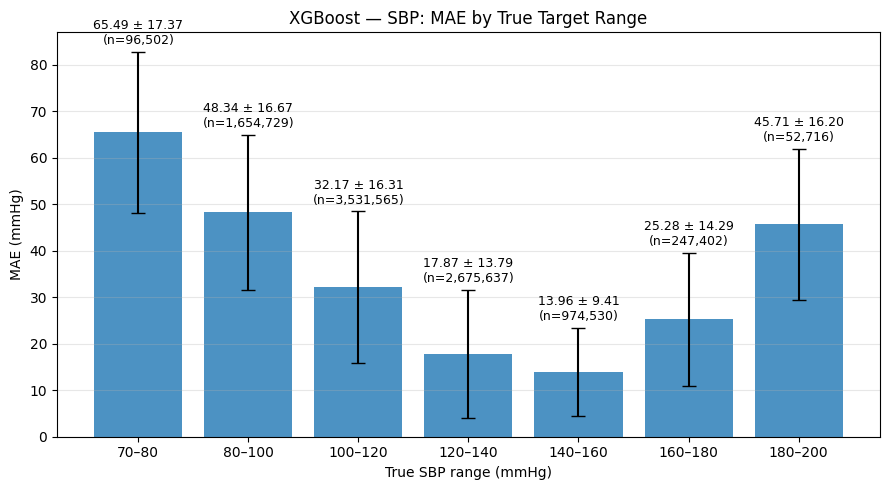

In [24]:
cross_gen(
    X_test_vital,
    y_test_vital,
    xgbmodel,
    "XGBoost",
    TARGET
)

## Light GBM ##

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time= 1.6min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time= 3.2min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time= 5.4min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time= 5.6min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=31; total time= 4.6min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=10.0min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=10.1min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=10.2min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=10.5min
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total ti

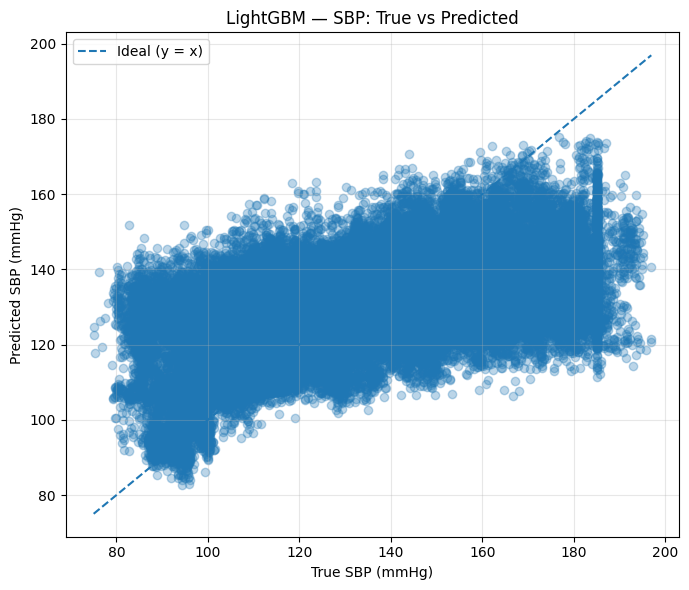

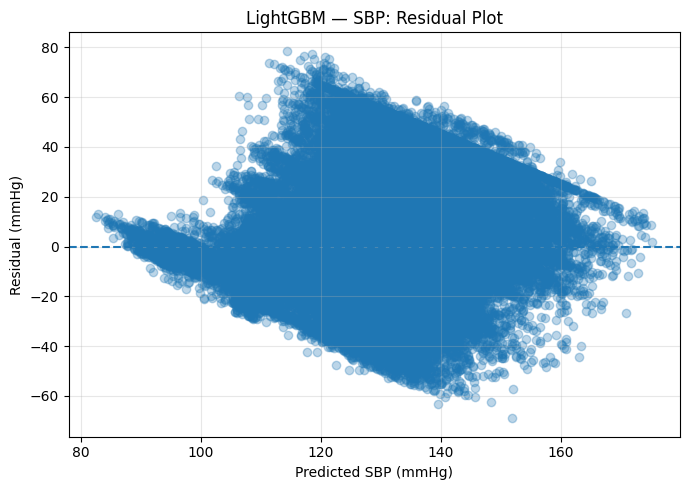

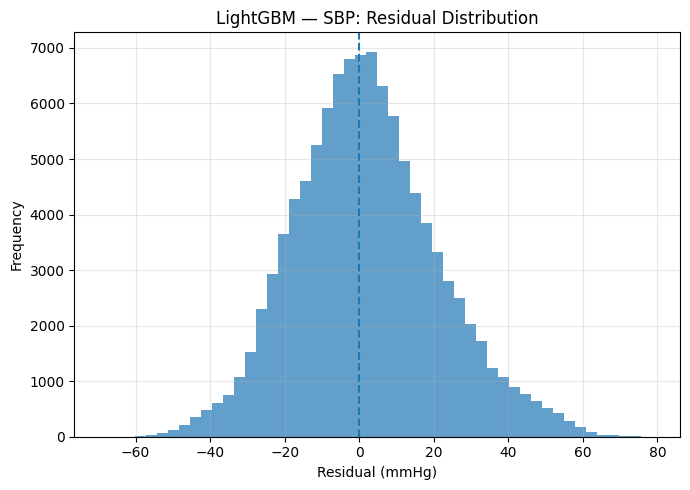

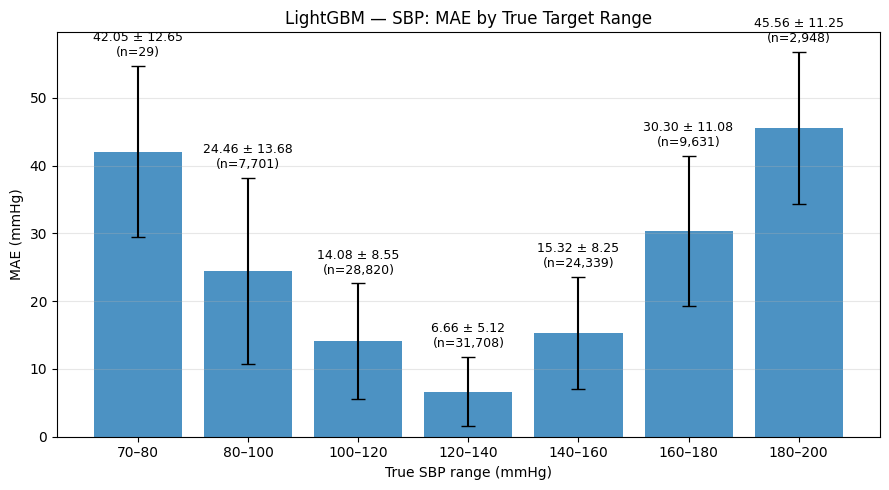

In [25]:
lgbmmodel, y_test_pred = lightgbm_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 32.5549
MSE : 1059.8202
R²  : -1.4797
MAE : 27.1944


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


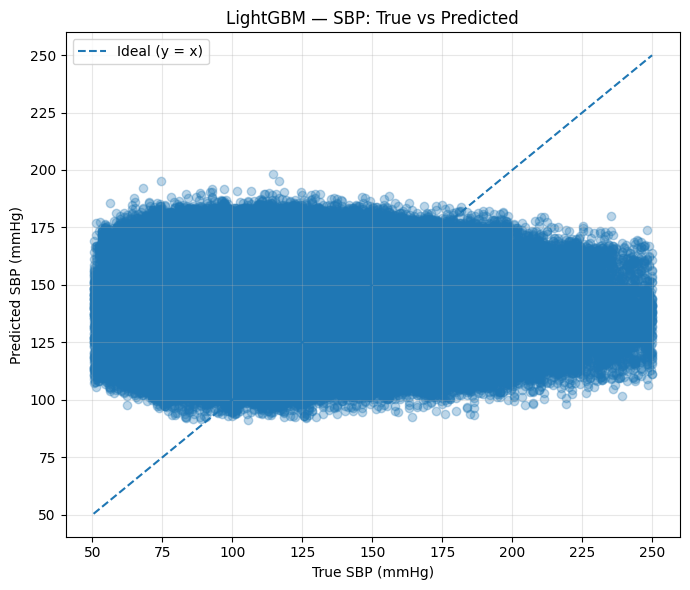

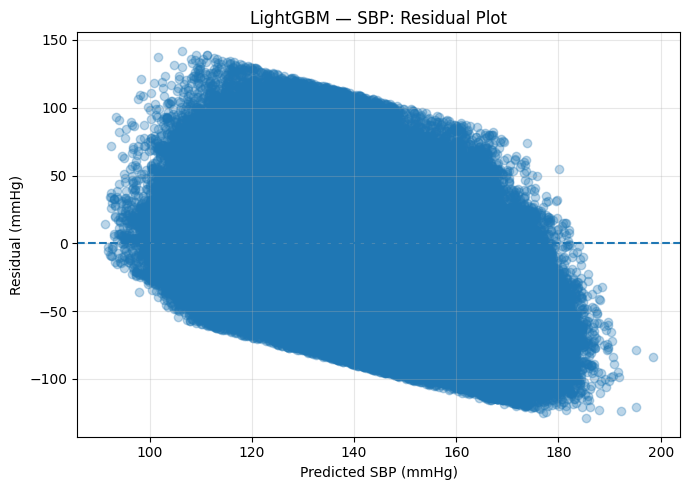

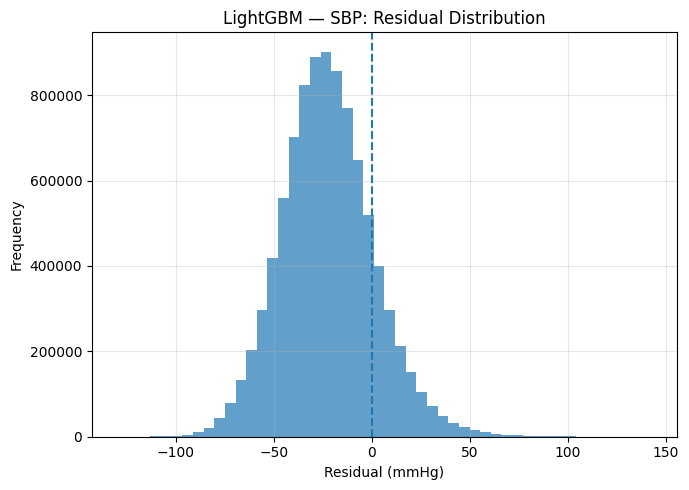

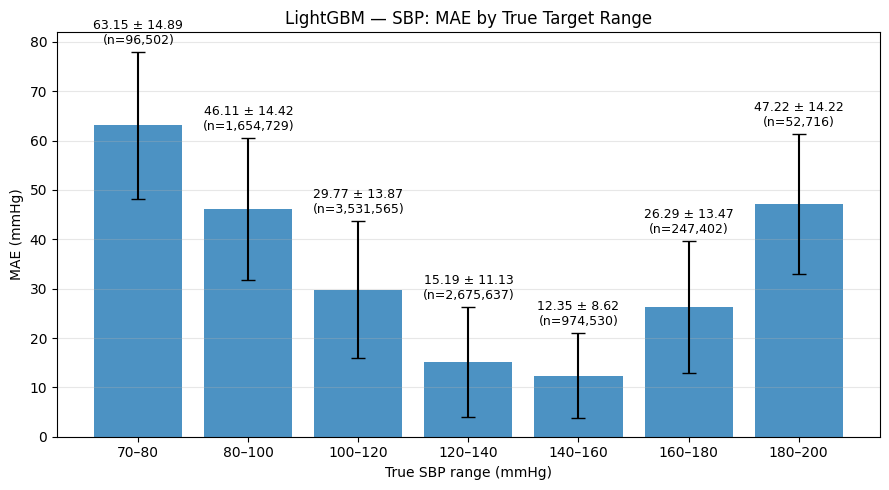

In [26]:
cross_gen(
    X_test_vital,
    y_test_vital,
    lgbmmodel,
    "LightGBM",
    TARGET
)

##  Matern 5/2 gpr ##

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Best parameters:
{'kernel': 1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1)}

Matern 5/2 GPR — SBP
--------------------------------
RMSE: 20.6115
MSE : 424.8337
R²  : 0.1952
MAE : 16.2810


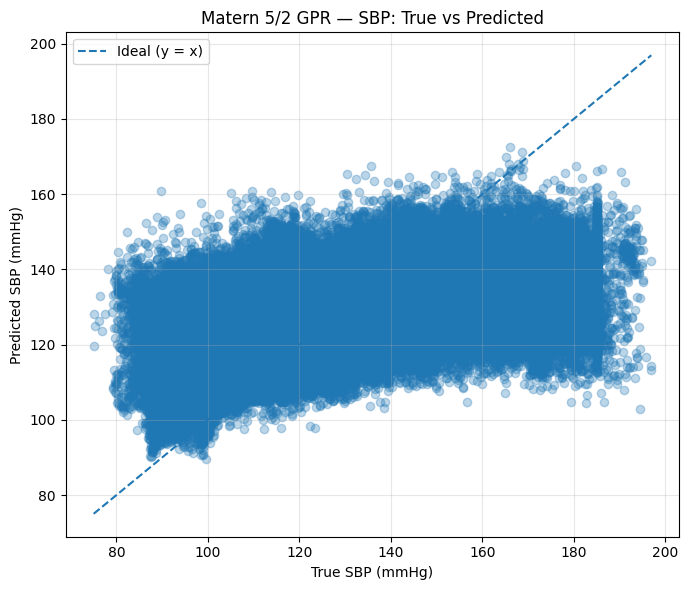

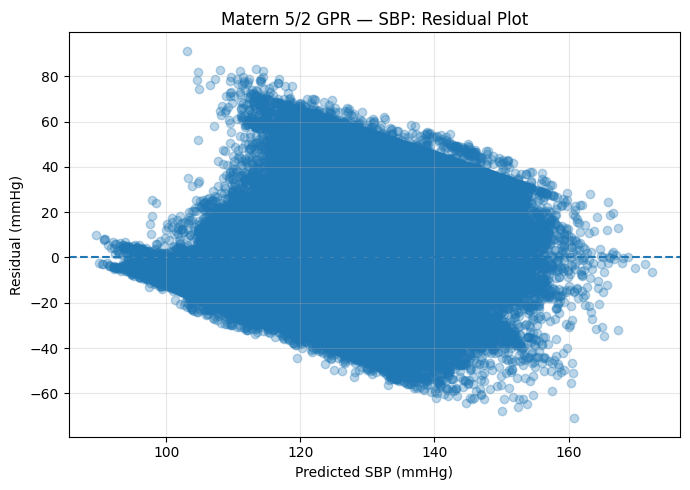

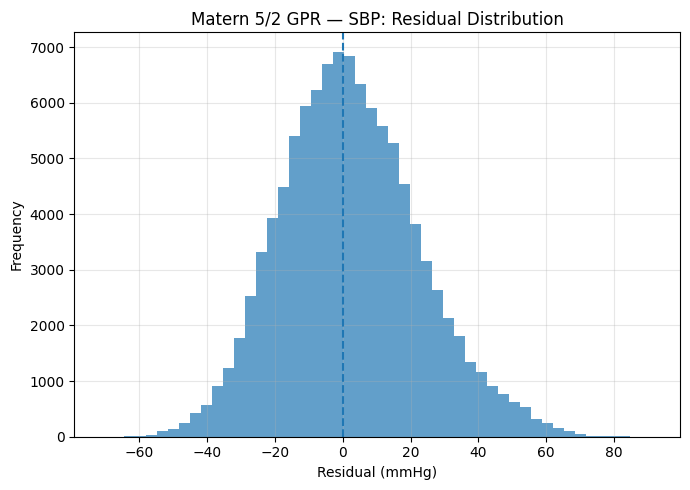

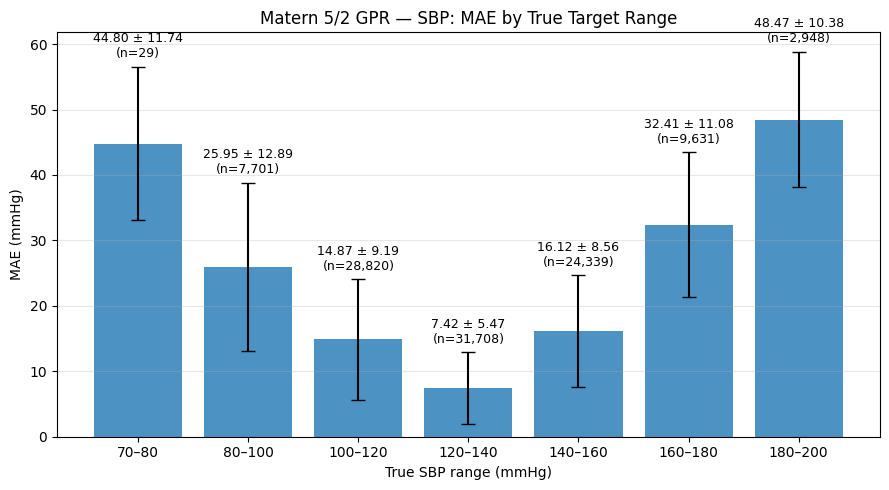

In [27]:
gpr_model, y_test_pred = gpr_matern(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 23.9689
MSE : 574.5085
R²  : -0.3442
MAE : 19.6899


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


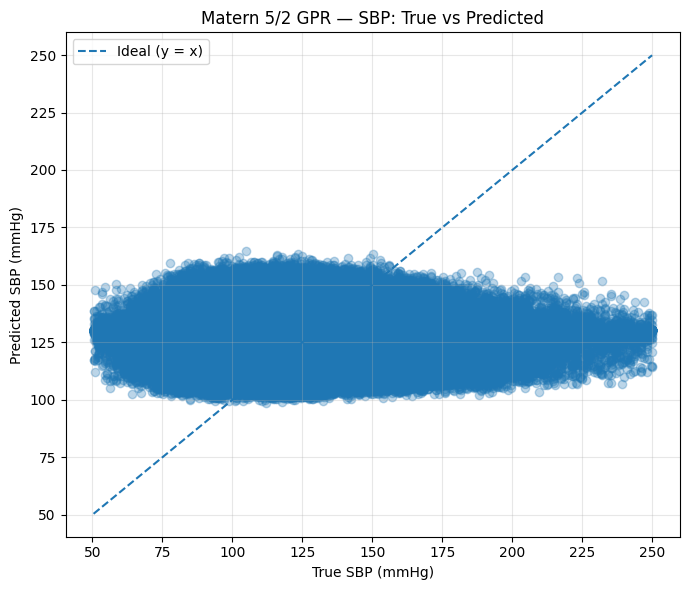

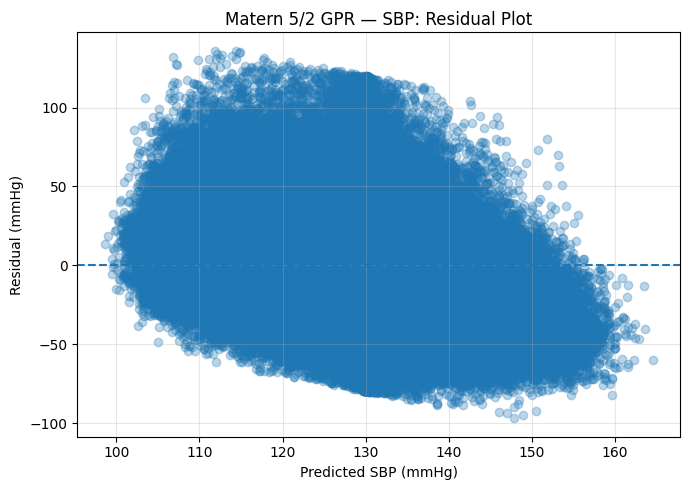

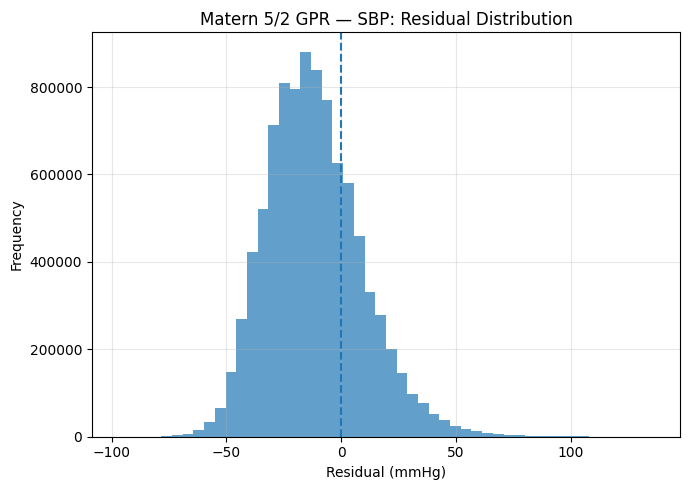

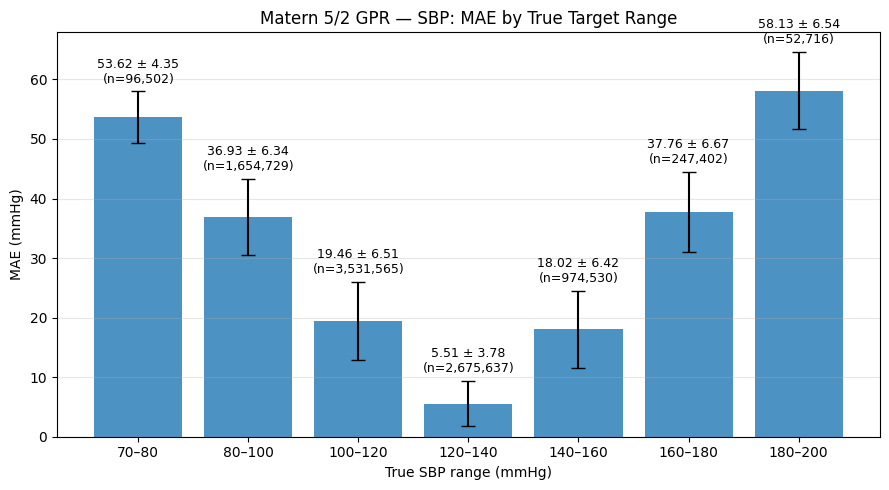

In [28]:
y_pred_vitaldb = predict_gpr_in_batches(
    model=gpr_model,
    X=X_test_vital,
    y_test=y_test_vital,
    target_name=TARGET,
    model_name="Matern 5/2 GPR",
    batch_size=10000
)

## Rational Quadratic GPR ##

GPR training samples: 5,000

Starting Rational Quadratic GPR GridSearch...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best parameters:
{'kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1)}

Best CV RMSE: 19.738971899257375

Best GPR model:
GaussianProcessRegressor(kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1),
                         normalize_y=True, random_state=42)

Starting batched prediction on 105,176 samples...
RMSE: 20.6378
MSE : 425.9196
R²  : 0.1931
MAE : 16.2658


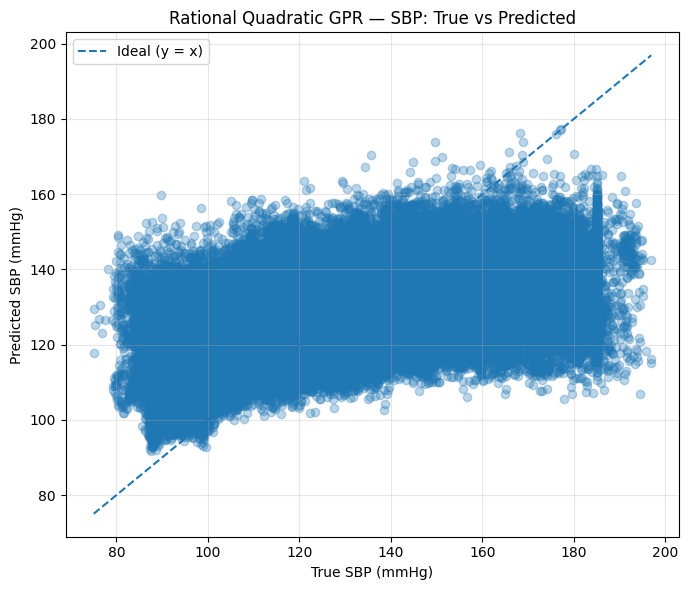

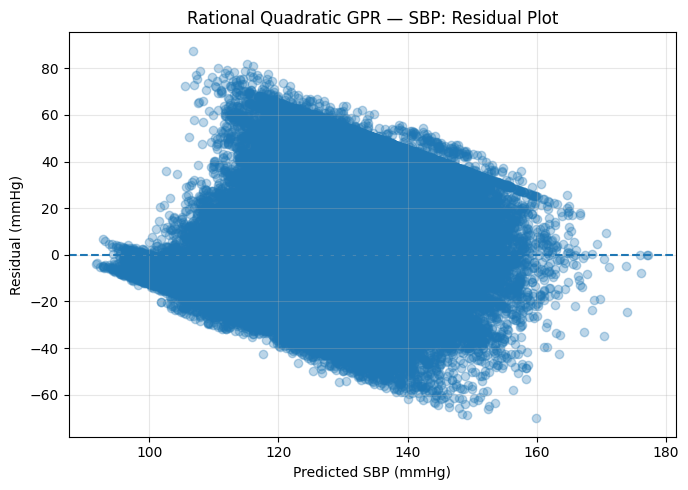

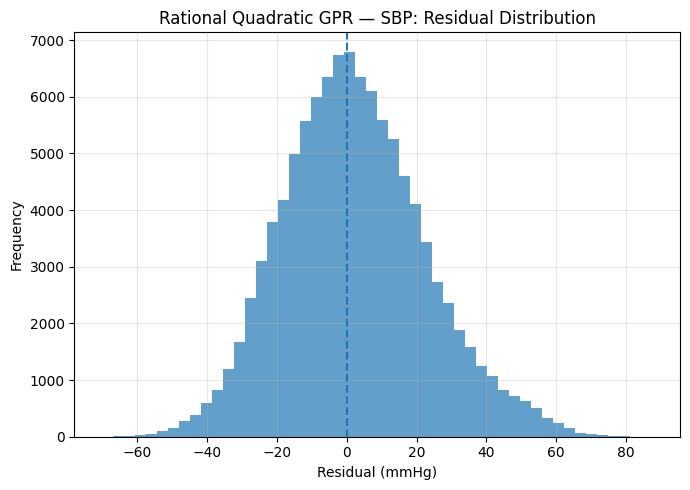

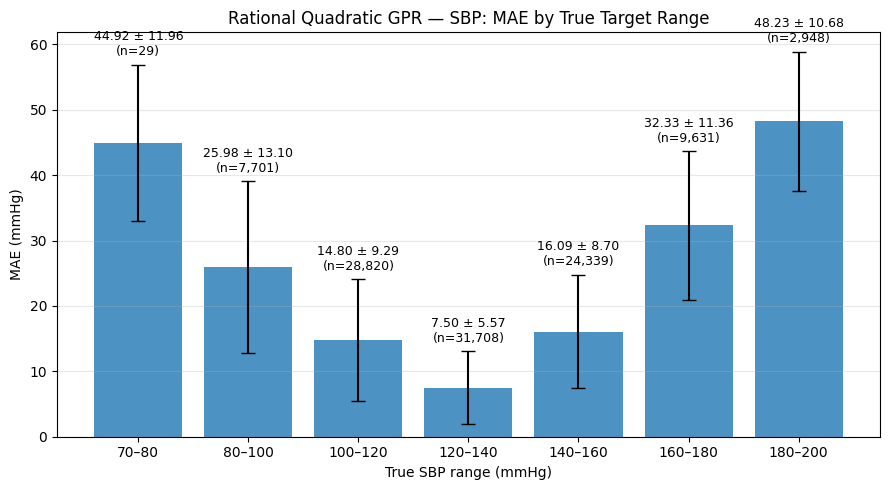

In [29]:
rq_model, y_test_pred = gpr_rational_quadratic(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 22.8260
MSE : 521.0248
R²  : -0.2191
MAE : 18.5282


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


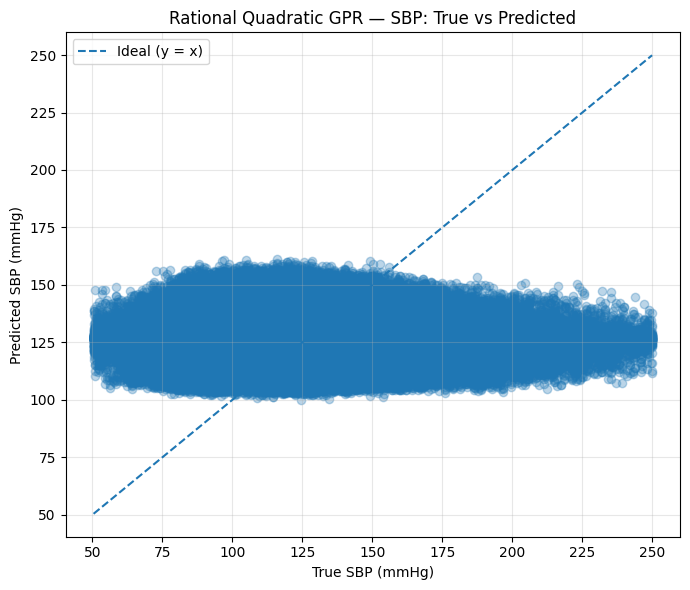

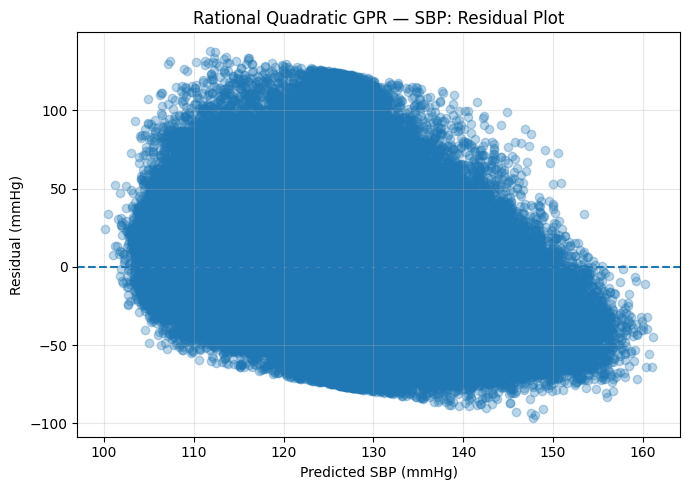

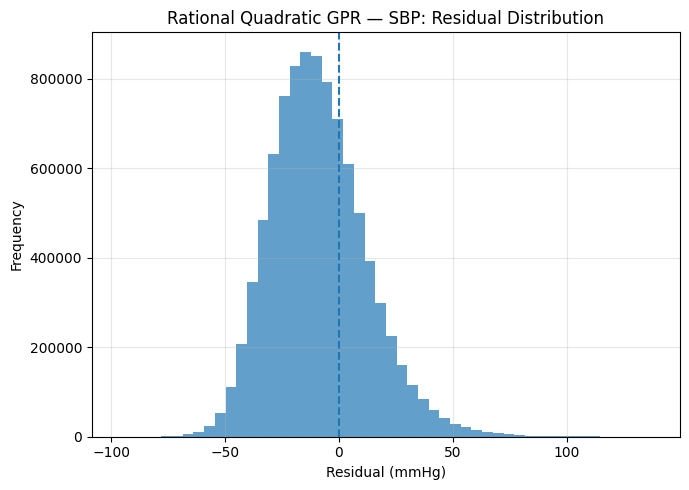

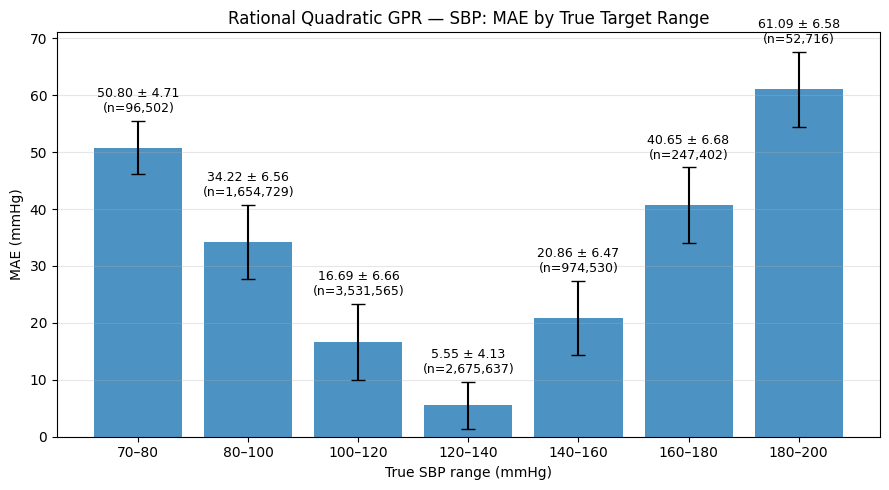

In [30]:
y_pred_vitaldb = predict_gpr_in_batches(
    rq_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Rational Quadratic GPR",
    batch_size=10000
)

## ANN ##

ANN training samples: 5,000

Starting ANN / MLP GridSearch...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum i


Best parameters:
{'activation': 'relu', 'alpha': 0.001, 'batch_size': 256, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}

Best CV RMSE: 20.885529120221687

Best ANN / MLP model:
MLPRegressor(alpha=0.001, batch_size=256, early_stopping=True,
             hidden_layer_sizes=(128, 64), max_iter=300, n_iter_no_change=20,
             random_state=42)

Starting batched prediction on 105,176 samples...
Processed 10,000 / 105,176
Processed 20,000 / 105,176
Processed 30,000 / 105,176
Processed 40,000 / 105,176
Processed 50,000 / 105,176
Processed 60,000 / 105,176
Processed 70,000 / 105,176
Processed 80,000 / 105,176
Processed 90,000 / 105,176
Processed 100,000 / 105,176
Processed 105,176 / 105,176

ANN / MLP Regressor — SBP
------------------------------------
RMSE: 21.1550
MSE : 447.5329
R²  : 0.1522
MAE : 16.5762


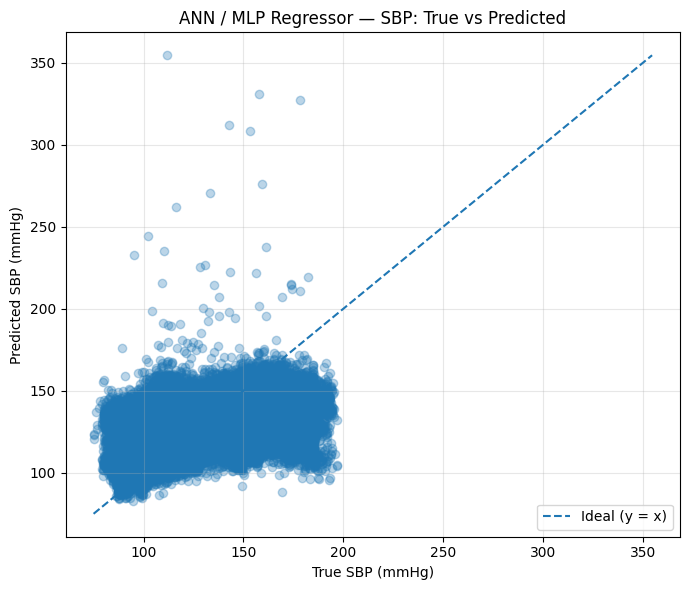

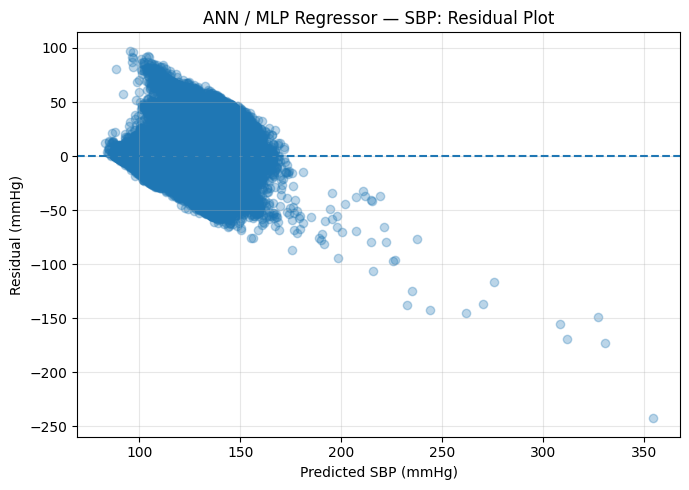

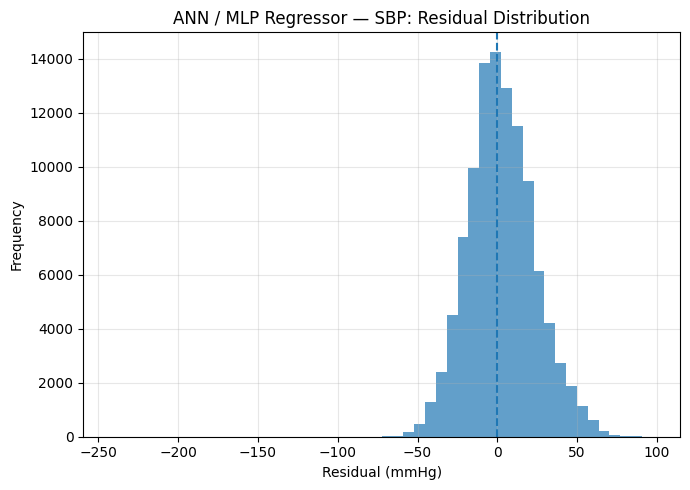

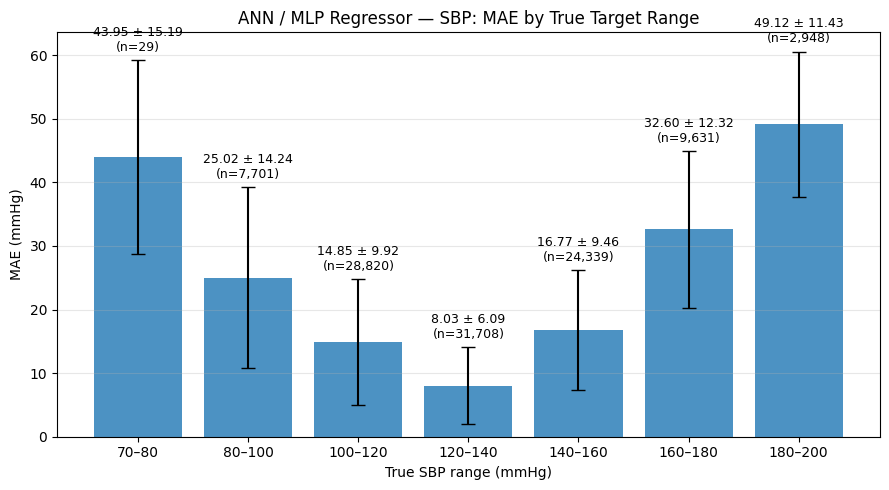

In [31]:
ann_model, y_test_pred = ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 484.4374
MSE : 234679.6036
R²  : -548.0837
MAE : 108.0018


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


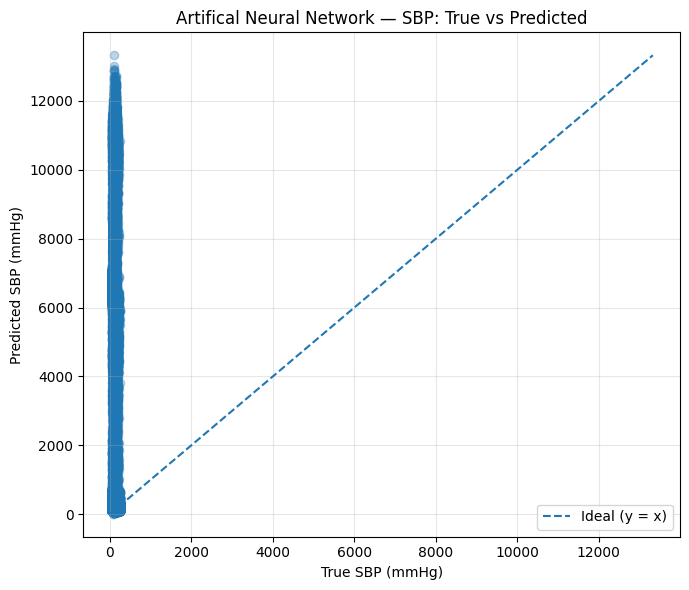

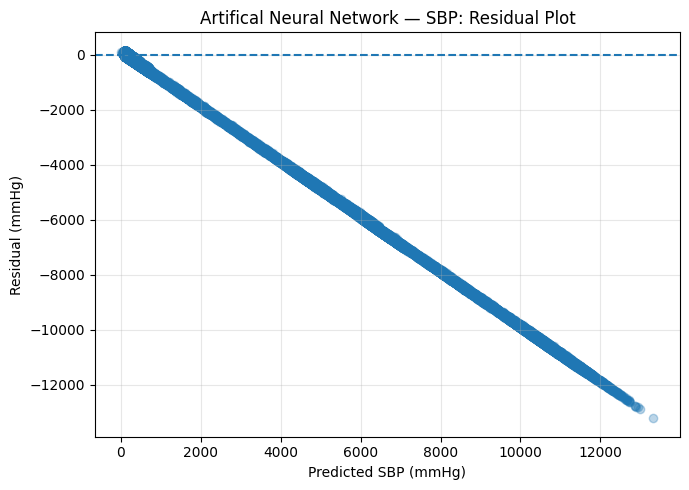

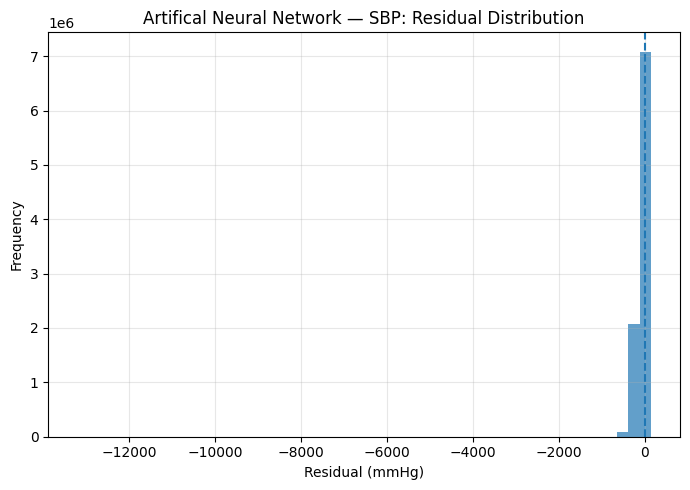

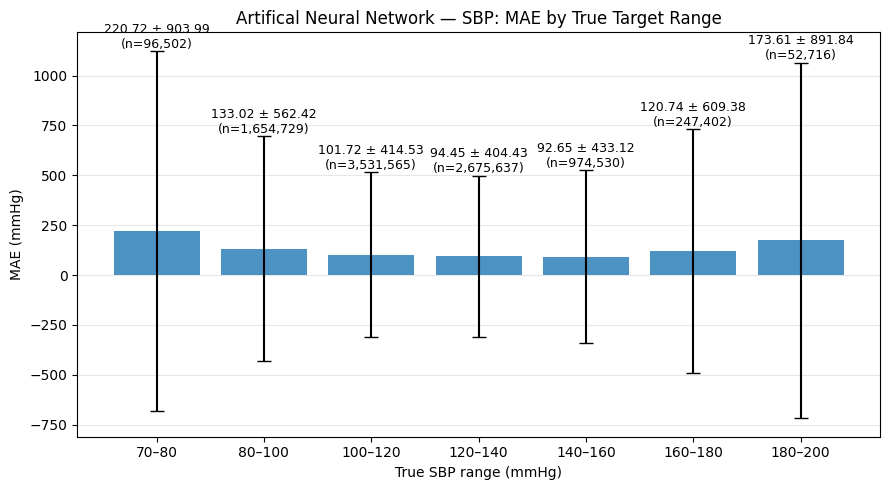

In [32]:
y_pred_vitaldb = predict_gpr_in_batches(
    ann_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Artifical Neural Network",
    batch_size=10000
)